<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB54 · Entorno de locomoción profesional 3D

**Parte 6 · Simulación de bípedos a fondo — Bloque C: del plano al 3D — Lección 2**

> En el NB43 y el NB44, Zancudo plano aprendió a andar con RL. Pero solo sabía hacer **una cosa**: ir hacia delante, lo más deprisa posible. Un robot de verdad no sirve para eso. Tiene que obedecer: "ve despacio", "para", "gira a la izquierda", "apártate de lado". Hoy montamos el entorno con el que se entrena **así** a los robots con patas en los laboratorios de verdad, con Zancudo 3D del NB53. Y lo montamos como lo montaría un profesional: un **paquete de Python instalable**, con su línea de órdenes, su registro y sus pruebas automáticas.

Lo que vas a construir hoy es, en pequeño, lo mismo que hay dentro de:

- **legged_gym** (ETH Zúrich, 2021): el artículo *"Learning to walk in minutes using massively parallel deep RL"*. Miles de robots ANYmal aprendiendo a la vez en una tarjeta gráfica. Su receta (órdenes de velocidad, gravedad proyectada, recompensa por términos) es la que copia todo el mundo desde entonces.
- **Isaac Lab** (NVIDIA): el sucesor de legged_gym, con humanoides como el H1 o el G1 de Unitree.
- **MuJoCo Playground** (Google DeepMind, 2025): lo mismo sobre MuJoCo, en GPU (lo usaremos en el NB60).

Si entiendes este notebook, podrás abrir el código de cualquiera de los tres y reconocer cada pieza.

Preguntas de entrevista que vas a poder contestar:

- "¿Qué observa una política de locomoción? ¿Por qué la gravedad proyectada? ¿Por qué no la posición?"
- "¿Por qué la acción es un desplazamiento sobre una postura por defecto y no un par?"
- "¿Qué es la decimación del control?"
- "Diseña la recompensa para seguir órdenes de velocidad. ¿Por qué exp(−error²/σ)?"
- "¿Qué diferencia hay entre *terminated* y *truncated*?"
- "¿Cómo organizarías el código de un proyecto de RL para que otros lo usen?"

Y en el hilo de Python, el salto de "código en un notebook" a "**proyecto**": `pyproject.toml`, instalar en modo editable, línea de órdenes con `argparse`, `logging` y pruebas con **fixtures** de pytest.

Un aviso de entrada, para que no haya sorpresas: entrenar un bípedo **en 3D** es caro. Los laboratorios lo hacen con miles de robots en una GPU; nosotros tenemos una Raspberry Pi con 4 núcleos. Aquí verás un entrenamiento corto en vivo (unos minutos) y los resultados de uno largo que se lanzó aparte, en segundo plano. Te contaré con honestidad hasta dónde llega cada uno.


In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"

import math
import sys
import time
from pathlib import Path

import mujoco
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True, linewidth=120)
print("MuJoCo", mujoco.__version__, "· Python", sys.version.split()[0])

MuJoCo 3.14.0 · Python 3.13.5


## 1 · Cómo entrenan a andar los profesionales

### La idea: un robot con mando

Piensa en un coche teledirigido. Tú mueves el mando: "adelante", "gira", "para". El coche no sabe adónde vas; solo obedece **la orden de este momento**. Los robots con patas de verdad funcionan igual: un humano con un mando (o un programa que planifica el camino) le dice al robot **a qué velocidad moverse**, y la política de locomoción se encarga de **cómo** mover las piernas para conseguirlo.

La orden son tres números:

| Orden | Qué pide | Unidades |
|---|---|---|
| **vx** | avanzar (o retroceder, si es negativa) | m/s |
| **vy** | moverse de lado (como un cangrejo) | m/s |
| **giro** | girar sobre sí mismo (guiñada, NB53) | rad/s |

Las tres, medidas **desde el robot**: "hacia delante" es hacia donde mira el torso, no hacia el norte del mundo. Es lo que haría el mando: "adelante" es adelante del coche.

### Una sola política para todas las órdenes

En el NB44, si querías que Zancudo fuera más despacio, había que **entrenar otra política** (la variante `lento`). Ahora no: la orden es **parte de la observación**. La red la lee, y aprende a comportarse distinto según lo que pida. Durante el entrenamiento, cada episodio recibe una orden **al azar**, así que la política ve de todo: rápido, lento, de lado, girando, quieto. Al final, **una sola red** sabe obedecer cualquier orden de ese rango.

### La tubería, de un vistazo

```
  orden (vx, vy, giro) ──┐
                         ▼
  sensores ──► observación ──► POLÍTICA (red) ──► acción ──► objetivo de los servos ──► servos PD ──► MuJoCo
     ▲          (50 números)    50 veces por s     (12 n.º)   postura + escala·acción   200 veces por s     │
     └──────────────────────────────────────────────────────────────────────────────────────────────────┘
```

Iremos pieza a pieza: **la orden** (sección 2), **la observación** (3), **la acción** y los dos relojes, el de la política y el de la física (4), **la recompensa** (5) y **el principio y el fin de cada episodio** (6). Primero con celdas pequeñas, sobre el robot "a pelo". Después (sección 7) lo ordenamos todo en un paquete.

Carguemos a Zancudo 3D tal y como lo guardamos en el NB53:


In [2]:
modelo = mujoco.MjModel.from_xml_path("robots/zancudo3d.xml")
datos = mujoco.MjData(modelo)
mujoco.mj_resetDataKeyframe(modelo, datos, modelo.key("agachado").id)
mujoco.mj_forward(modelo, datos)
TORSO = modelo.body("torso").id
print(f"nq = {modelo.nq}, nv = {modelo.nv}, nu = {modelo.nu}, paso de la física = {modelo.opt.timestep} s")

nq = 19, nv = 18, nu = 12, paso de la física = 0.002 s


Lo de siempre: 19 números de posición, 18 de velocidad, 12 motores (NB53). El paso de la física, 0,002 s; dentro de un rato lo cambiaremos.

## 2 · Las órdenes de velocidad

### Muestrear una orden

Al empezar cada episodio, se sortea una orden: cada número, **uniforme** entre un mínimo y un máximo (NB28). Los rangos los elegimos nosotros, y son una decisión importante: si pides cosas imposibles (correr a 3 m/s), la política se frustra y no aprende nada; si pides poco, no aprende lo que querías. Para Zancudo, que mide lo que una persona pequeña y tiene servos de juguete, empezamos modestos:

| Orden | Rango |
|---|---|
| vx | de −0,3 a 0,6 m/s (hacia atrás, algo menos) |
| vy | de −0,2 a 0,2 m/s |
| giro | de −0,5 a 0,5 rad/s |

Y un detalle que se olvida mucho: **"quieto" también es una orden**. Si nunca se la pides, la política no sabrá pararse (siempre ha estado andando). Por eso, en el 10 % de los episodios, la orden es (0, 0, 0).


In [3]:
rng = np.random.default_rng(0)

def muestrear_orden(rng):
    if rng.random() < 0.1:                       # el 10 % de las veces: «quieto»
        return np.zeros(3)
    return np.array([rng.uniform(-0.3, 0.6), rng.uniform(-0.2, 0.2), rng.uniform(-0.5, 0.5)])

for _ in range(5):
    print(muestrear_orden(rng))

[-0.0572 -0.1836 -0.4835]
[0.5215 0.0427 0.2295]
[ 0.5416  0.1263 -0.4973]
[-0.2698  0.0919 -0.3243]
[ 0.1873 -0.0801 -0.0773]


Cinco episodios, cinco órdenes distintas. (`rng.random()` da un número entre 0 y 1: es menor que 0,1 una de cada diez veces.)

En legged_gym, además, la orden **cambia a mitad de episodio** cada pocos segundos, para que el robot aprenda también a **pasar** de una velocidad a otra. Nosotros, de momento, una orden por episodio (el plan del curso): es más fácil de aprender y de medir. Cambiarla a mitad es uno de los ejercicios.

## 3 · La observación: lo que siente el robot

Ahora la pieza más importante del diseño. ¿Qué números le damos a la red? La regla de oro de los profesionales:

> **Solo lo que un robot de verdad podría medir con sus sensores**, y expresado **desde el punto de vista del robot**.

Por dos motivos. Uno, práctico: si la política aprende a usar algo que el robot real no tiene, no funcionará fuera del simulador (el *sim-to-real* del NB61). Dos, de aprendizaje: si el mundo es igual visto desde el robot, la política debería hacer lo mismo, y conviene que **los números también sean iguales** (lo vemos en 3.7).

Vamos con cada pieza.

### 3.1 · La gravedad proyectada

¿Cómo sabe el robot si está derecho o inclinado? En el Zancudo plano le dábamos "el ángulo del torso". En 3D, la orientación son tres ángulos (o un cuaternión, NB46), y los ángulos de Euler tienen problemas (saltos de 360°, singularidades...). La solución que usa todo el mundo es preciosa por lo sencilla: **dónde está "abajo", visto desde el torso**.

Es el vector (0, 0, −1) del mundo (la gravedad, apuntando hacia abajo, de longitud 1), expresado en los ejes **del torso**. Ya lo hiciste en el E1 del NB53: con la matriz de rotación del torso R (cuyas columnas son los ejes del torso vistos desde el mundo, NB46), pasar un vector del mundo al marco del torso es multiplicar por la **traspuesta**: Rᵀ · v.


In [4]:
def gravedad_proyectada(datos):
    R = datos.xmat[TORSO].reshape(3, 3)          # ejes del torso, vistos desde el mundo
    return R.T @ np.array([0.0, 0.0, -1.0])      # «abajo», visto desde el torso

print("de pie:", gravedad_proyectada(datos))

de pie: [ 0.  0. -1.]


De pie y derecho, **(0, 0, −1)**: "abajo" está justo debajo del torso. Ahora inclinémoslo 0,3 rad hacia delante (un giro alrededor del eje y; el cuaternión de un giro de θ alrededor de un eje es (cos θ/2, sen θ/2 · eje), NB46):


In [5]:
def girar_torso(datos, angulo, eje):
    '''Pone el torso girado `angulo` rad alrededor de `eje` (sin tocar las piernas).'''
    eje = np.asarray(eje, dtype=float) / np.linalg.norm(eje)
    datos.qpos[3:7] = [math.cos(angulo / 2), *(math.sin(angulo / 2) * eje)]
    mujoco.mj_forward(modelo, datos)

girar_torso(datos, 0.3, [0, 1, 0])
print("inclinado 0,3 rad hacia delante:", gravedad_proyectada(datos))
print("sen(0,3) =", round(math.sin(0.3), 4), "  cos(0,3) =", round(math.cos(0.3), 4))

inclinado 0,3 rad hacia delante: [ 0.2955  0.     -0.9553]
sen(0,3) = 0.2955   cos(0,3) = 0.9553


Con el torso inclinado hacia delante, "abajo" ya no está justo debajo de él: desde su punto de vista, queda un poco **hacia delante** (hacia su pecho), (0,2955, 0, −0,9553), es decir, (sen 0,3, 0, −cos 0,3). Piensa en ti mismo inclinado hacia delante: el suelo que tienes justo debajo de los pies queda "delante y abajo" de tu tronco. Las dos primeras componentes dicen **cuánto y hacia dónde** está inclinado. Y ahora, la propiedad mágica. Giremos el torso 90° alrededor del eje **vertical** (cambiar de rumbo, como quien se da la vuelta):


In [6]:
girar_torso(datos, math.pi / 2, [0, 0, 1])
print("mirando hacia otro lado:", gravedad_proyectada(datos))

mirando hacia otro lado: [ 0.  0. -1.]


**(0, 0, −1)**, exactamente igual que mirando al frente. La gravedad proyectada **no sabe hacia dónde mira el robot**, solo si está derecho. Y eso es justo lo que queremos: para mantener el equilibrio, da igual mirar al norte o al sur. Con ángulos de Euler, el rumbo se colaría en los números.

Además, se puede **medir** con una IMU barata: un acelerómetro quieto mide la reacción a la gravedad, un vector que apunta hacia **arriba** con 9,81 m/s² (NB41). Así que gravedad proyectada ≈ −aceleración / |aceleración|. Lo comprobarás en la práctica del final.

### 3.2 · La velocidad angular: el giróscopo

Ya lo sabes del NB53: en una junta libre, `qvel[3:6]` es la velocidad angular **en el marco del torso**. Justo lo que mide un giróscopo atornillado al torso. Comprobémoslo con el sensor `giroscopo` que pusimos en el NB53 (en el site `imu`, que tiene los mismos ejes que el torso):


In [7]:
mujoco.mj_resetDataKeyframe(modelo, datos, modelo.key("agachado").id)
girar_torso(datos, 0.7, [0, 0, 1])               # mirando a otro lado, para que se note
datos.qvel[3:6] = [0.5, -0.2, 1.0]
mujoco.mj_forward(modelo, datos)
print("qvel[3:6]:            ", datos.qvel[3:6])
print("sensor del giróscopo: ", datos.sensor("giroscopo").data)

qvel[3:6]:             [ 0.5 -0.2  1. ]
sensor del giróscopo:  [ 0.5 -0.2  1. ]


Idénticos. La velocidad angular entra en la observación tal cual, sin hacer cuentas.

### 3.3 · La velocidad lineal, en el marco del torso

La velocidad **lineal**, en cambio, `qvel[0:3]`, está en el marco del **mundo** (NB53). Para que "adelante" sea "hacia donde mira el robot", hay que girarla igual que la gravedad: Rᵀ · v. Con el torso mirando 0,7 rad hacia la izquierda y moviéndose a 0,5 m/s en la x **del mundo**:


In [8]:
datos.qvel[0:3] = [0.5, 0.0, 0.0]
mujoco.mj_forward(modelo, datos)
R = datos.xmat[TORSO].reshape(3, 3)
print("en el mundo:     ", datos.qvel[0:3])
print("desde el torso:  ", R.T @ datos.qvel[0:3])
print("comprobación:     0,5·cos(0,7) =", round(0.5 * math.cos(0.7), 4), "  −0,5·sen(0,7) =", round(-0.5 * math.sin(0.7), 4))

en el mundo:      [0.5 0.  0. ]
desde el torso:   [ 0.3824 -0.3221  0.    ]
comprobación:     0,5·cos(0,7) = 0.3824   −0,5·sen(0,7) = -0.3221


Desde el torso, el robot va 0,38 m/s hacia delante y 0,32 m/s **hacia su derecha** (y negativa). Esta es la velocidad que se compara con la orden.

Una advertencia honesta: esta pieza es **privilegiada**. Un robot real no tiene un sensor de velocidad lineal: la tiene que **estimar** (integrando el acelerómetro, con la cinemática de las patas apoyadas, con un filtro de Kalman...), y la estimación tiene error. Algunos equipos la quitan de la observación (las políticas de Unitree para el G1, por ejemplo) y la red se las arregla con el resto; otros la estiman con otra red. Aquí la dejamos, porque **acelera mucho el aprendizaje**, y en la Pi cada minuto cuenta. Lo retomaremos en el NB61.

### 3.4 · Las articulaciones, relativas a la postura por defecto

Los 12 ángulos de los motores (`qpos[7:]`) y sus 12 velocidades (`qvel[6:]`). Con un retoque: a los ángulos les **restamos la postura por defecto**, la de pie agachado del NB53 (`agachado`: cadera 0,5, rodilla −1, tobillo 0,5). Así, "de pie normal" son **doce ceros**, y la red ve **desviaciones**: "la rodilla derecha está 0,1 más doblada de lo normal". Los números quedan centrados en 0, que es donde las redes trabajan mejor (NB19).


In [9]:
POSTURA = modelo.key("agachado").qpos[7:].copy()
print("postura por defecto:", POSTURA)
print("ángulos relativos, de pie:", datos.qpos[7:] - POSTURA)

postura por defecto: [ 0.   0.   0.5 -1.   0.5  0.   0.   0.   0.5 -1.   0.5  0. ]
ángulos relativos, de pie: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### 3.5 · La última acción

Le damos a la red **lo que ella misma decidió en el paso anterior** (12 números). Parece raro: ¿no lo sabe ya? No: una red como las nuestras **no tiene memoria**; cada decisión empieza de cero. Y lo que decidió hace un instante importa, porque los servos **todavía están persiguiendo** aquel objetivo. Sin esto, el estado no sería completo (la propiedad de Markov, NB30: el futuro debería depender solo de lo que se observa ahora). Además, ayuda a que la red aprenda a moverse **suave**: puede ver cuánto va a cambiar respecto a lo anterior.

### 3.6 · La orden y el reloj de fase

La **orden** (vx, vy, giro) va dentro, por supuesto: es lo que hace que una sola red obedezca a todo.

Y un **reloj de fase**, como en el NB43: un número que da una vuelta cada 0,8 s (dos pasos: uno con cada pie). Le da a la red un ritmo al que agarrarse ("ahora le toca al pie derecho"), y facilita muchísimo que aparezca una marcha alterna. Es un truco muy usado en bípedos (está en las políticas de Unitree para H1 y G1).

¿Por qué se le da como **(seno, coseno)** del ángulo, y no la fase tal cual, un número de 0 a 1? Porque al dar la vuelta, la fase salta de 0,99 a 0: dos instantes **casi iguales** con números **muy distintos**. Con el seno y el coseno, el reloj es un punto que da vueltas en un círculo (NB36), sin saltos:


In [10]:
for t in [0.0, 0.2, 0.4, 0.79, 0.8]:
    fase = (t / 0.8) % 1.0
    angulo = 2 * math.pi * fase
    print(f"t = {t:4.2f} s → fase {fase:4.2f} → (sen, cos) = ({math.sin(angulo):+.3f}, {math.cos(angulo):+.3f})")

t = 0.00 s → fase 0.00 → (sen, cos) = (+0.000, +1.000)
t = 0.20 s → fase 0.25 → (sen, cos) = (+1.000, +0.000)
t = 0.40 s → fase 0.50 → (sen, cos) = (+0.000, -1.000)
t = 0.79 s → fase 0.99 → (sen, cos) = (-0.078, +0.997)
t = 0.80 s → fase 0.00 → (sen, cos) = (+0.000, +1.000)


En t = 0,79 y t = 0,8, la fase salta de 0,99 a 0, pero (sen, cos) apenas cambia.

### 3.7 · Lo que NO se observa: la posición

Fíjate en lo que **falta**: ni la posición x, y del robot en el mundo, ni hacia dónde mira (su rumbo). Ni siquiera la altura exacta. ¿Por qué, si el simulador lo sabe?

1. **Un robot real no lo sabe** (no lleva GPS de precisión milimétrica, y en interiores no hay GPS).
2. **No debería importar**. Andar a 0,5 m/s es lo mismo en el origen que a 100 metros, mirando al norte o al este. Si le das la posición a la red, la red tiene que **descubrir** que da igual... y mientras tanto puede aprender cosas que solo valen en las casillas del suelo por las que pasó al entrenar (se llama **sobreajuste**, NB18). Si no se la das, la política es igual en todas partes **por construcción**.

Esto tiene un nombre: la observación es **invariante** a la traslación y al rumbo. Comprobémoslo: juntamos las piezas de esta sección (sin la acción ni el reloj, que no dependen del robot) y comparamos dos robots en la misma postura, uno en el origen y otro 5 metros más allá y mirando a otro lado:


In [11]:
def observar(datos, orden):
    R = datos.xmat[TORSO].reshape(3, 3)
    return np.concatenate([R.T @ [0, 0, -1.0], datos.qvel[3:6], R.T @ datos.qvel[0:3], orden,
                           datos.qpos[7:] - POSTURA, datos.qvel[6:]])

def preparar(x, y, rumbo):
    d = mujoco.MjData(modelo)
    mujoco.mj_resetDataKeyframe(modelo, d, modelo.key("agachado").id)
    d.qpos[0:2] = x, y
    d.qpos[3:7] = [math.cos(rumbo / 2), 0, 0, math.sin(rumbo / 2)]
    d.qvel[:] = 0.1                                  # unas velocidades cualesquiera, iguales en el marco del torso...
    R = np.array([[math.cos(rumbo), -math.sin(rumbo), 0], [math.sin(rumbo), math.cos(rumbo), 0], [0, 0, 1]])
    d.qvel[0:3] = R @ [0.1, 0.1, 0.1]                # ...así que la lineal se gira al mundo
    mujoco.mj_forward(modelo, d)
    return d

orden = np.array([0.4, 0.0, 0.0])
a, b = preparar(0, 0, 0), preparar(5, -3, 1.2)
print("¿misma observación?", np.allclose(observar(a, orden), observar(b, orden)))

¿misma observación? True


**La misma**: para la política, los dos robots están en la misma situación, y harán exactamente lo mismo. (La velocidad lineal la hemos girado al mundo con la matriz del rumbo, porque `qvel[0:3]` está en el marco del mundo: queremos el **mismo** movimiento visto desde cada robot.)

### 3.8 · Escalas: todos los números, del mismo tamaño

Último detalle. Las piezas tienen tamaños muy distintos: la gravedad, entre −1 y 1; las velocidades articulares, hasta 20 rad/s. Como en el NB19, a la red le cuesta aprender si unas entradas son mil veces mayores que otras. legged_gym multiplica cada pieza por una **escala** fija para que todas anden por ±1: la velocidad angular por 0,25, las articulares por 0,05, la lineal por 2. Y encima, `VecNormalize` de SB3 (NB35) normaliza con la media y la desviación que va midiendo. Las dos cosas a la vez no estorban.

En resumen, la observación de Zancudo 3D tiene **50 números**:

| Pieza | Números | Viene de | ¿Se puede medir en un robot real? |
|---|---|---|---|
| gravedad proyectada | 3 | Rᵀ · (0, 0, −1) | sí: acelerómetro (+ giróscopo, con un filtro) |
| velocidad angular | 3 | `qvel[3:6]` | sí: giróscopo |
| velocidad lineal | 3 | Rᵀ · `qvel[0:3]` | **estimada** (privilegiada) |
| orden | 3 | el sorteo | sí: el mando |
| ángulos − postura | 12 | `qpos[7:]` | sí: codificadores de los motores |
| velocidades articulares | 12 | `qvel[6:]` | sí: codificadores |
| última acción | 12 | la red | sí: la recuerda el ordenador |
| reloj de fase | 2 | el tiempo | sí |


## 4 · La acción: desplazamientos, servos y dos relojes

### Desplazamiento sobre la postura por defecto

La red da 12 números entre −1 y 1. ¿Qué significan? Como en el NB43, **no son pares**: son **objetivos de los servos** (NB40). Pero centrados en la postura por defecto:

```
objetivo  =  postura por defecto  +  escala × acción          (escala = 0,3 rad)
```

Con acción 0, el objetivo es **estar de pie** en la postura de siempre. Esto es muy importante al principio del entrenamiento: la red recién nacida da acciones pequeñas y al azar, alrededor de 0, así que el robot empieza **más o menos de pie**, en vez de retorcerse en el suelo. Aprende **correcciones** sobre algo que ya casi funciona. Y la **escala** limita cuánto puede apartarse cada articulación: con 0,3 rad (17°) en la cadera, la pierna puede adelantarse unos 25 cm: suficiente para dar pasos, sin dar patadas locas.


In [12]:
ESCALA = 0.3
accion = np.random.default_rng(1).uniform(-1, 1, 12)
objetivo = POSTURA + ESCALA * accion
bajo, alto = modelo.actuator_ctrlrange.T
print("acción:  ", accion)
print("objetivo:", np.clip(objetivo, bajo, alto))

acción:  

 [ 0.0236  0.9009 -0.7117  0.8973 -0.3763 -0.1533  0.6554 -0.1816  0.0992 -0.9449  0.507   0.0763]
objetivo: [ 0.0071  0.2703  0.2865 -0.7308  0.3871 -0.046   0.1966 -0.0545  0.5298 -1.2835  0.6521  0.0229]


(`np.clip` con los rangos de los motores, `actuator_ctrlrange`, por si el objetivo se sale de lo que la articulación permite. El `.T` traspone la tabla de 12 × 2 para separar mínimos y máximos en dos líneas, P6.)

### Servos blandos

En el NB53 vimos que los servos **blandos** (kp = 300) son más seguros y que, con buena prealimentación, sostienen igual. Con RL no hay prealimentación calculada a mano: la red **aprende** a pedir un objetivo un poco más allá para compensar lo que el servo "se hunde". Los equipos profesionales usan servos blandos para entrenar con RL, porque la rigidez exagerada hace que cualquier pequeño error de la red sea un tirón brusco. Usaremos kp = 300 y kv = 10.

Recuerda la trampa del NB50: un actuador de posición de MuJoCo guarda kp **dos veces**, en la ganancia (`gainprm[0]`) y en el sesgo (`biasprm[1] = −kp`); y kv en `biasprm[2] = −kv`. Hay que cambiar las tres cosas:


In [13]:
modelo.actuator_gainprm[:, 0] = 300.0
modelo.actuator_biasprm[:, 1] = -300.0
modelo.actuator_biasprm[:, 2] = -10.0
print("motor 0:", modelo.actuator_gainprm[0, :1], modelo.actuator_biasprm[0, :3])

motor 0: [300.] [   0. -300.  -10.]


### Dos relojes: la física y la política

La física y la política no van al mismo ritmo:

- **La física** (y los servos PD) avanza en pasitos de **0,005 s**: 200 veces por segundo. En un robot real, el bucle PD corre todavía más rápido, en el propio controlador del motor (1.000 veces por segundo o más).
- **La política** decide cada **0,02 s**: 50 veces por segundo. Entre una decisión y la siguiente, el objetivo de los servos se queda fijo, y la física da **4 pasitos**.

A esto se le llama **decimación** (*decimation*): por cada decisión de la política, `decimacion` pasos de física. ¿Por qué no decidir en cada pasito?

1. **Coste**: la red es mucho más cara que un paso de física. Vamos a medirlo.
2. **Aprender es más fácil** con decisiones menos frecuentes: un episodio de 10 s son 500 decisiones, no 2.000, y cada decisión tiene un efecto visible (el "descuento" del NB30 alcanza más lejos en el tiempo).
3. **Es lo realista**: un robot real no puede pensar 1.000 veces por segundo con una red, pero sus servos sí pueden corregir a ese ritmo.

Midamos lo que cuesta un paso de física de Zancudo 3D, y una pasada por una red como la que usaremos (50 entradas, dos capas de 256 y 128, 12 salidas):


In [14]:
import torch
torch.set_num_threads(1)

modelo.opt.timestep = 0.005
mujoco.mj_resetDataKeyframe(modelo, datos, modelo.key("agachado").id)
inicio = time.perf_counter()
for _ in range(2000):
    mujoco.mj_step(modelo, datos)
fisica = (time.perf_counter() - inicio) / 2000

red = torch.nn.Sequential(torch.nn.Linear(50, 256), torch.nn.ELU(), torch.nn.Linear(256, 128), torch.nn.ELU(),
                          torch.nn.Linear(128, 12))
x = torch.zeros(1, 50)
with torch.no_grad():
    inicio = time.perf_counter()
    for _ in range(2000):
        red(x)
pensar = (time.perf_counter() - inicio) / 2000
print(f"un paso de física: {fisica * 1e6:.0f} µs   una decisión de la red: {pensar * 1e6:.0f} µs")
print(f"¿sigue de pie tras 10 s con dt = 0,005 y servos blandos? altura del torso {datos.qpos[2]:.3f} m")

un paso de física: 37 µs   una decisión de la red: 431 µs
¿sigue de pie tras 10 s con dt = 0,005 y servos blandos? altura del torso 0.757 m


La red cuesta **más** que un paso de física, varias veces más (y en el entrenamiento, además, hay que aprender de cada decisión). Con 4 pasos de física por decisión, la física deja de ser lo caro.

Y fíjate en la última línea: con un paso de 0,005 s (2,5 veces más grande que el de fábrica) y servos blandos, Zancudo sigue de pie, estable, gracias al integrador `implicitfast` que elegimos en el NB53 (NB49: con Euler, el tobillo del Zancudo plano ya vibraba con pasos pequeños). Un paso más grande es **simulación más rápida**: 2,5 veces menos pasos por segundo de robot.

## 5 · La recompensa modular

### La campana: exp(−error²/σ)

¿Cómo se premia "seguir la orden"? Lo natural sería castigar el error: −(orden − velocidad)². Pero los profesionales usan casi siempre esta otra forma:

```
premio  =  exp(−error² / σ)
```

Es una **campana** (NB15b): vale **1** cuando el error es 0, y va bajando hacia 0 a medida que el error crece. σ (sigma) controla lo **ancha** que es: con σ = 0,25, un error de 0,5 m/s (error² = 0,25) da exp(−1) = 0,37. ¿Por qué es mejor que el castigo cuadrático?

1. **Está acotada** entre 0 y 1. Un error enorme (al caerse) no da un castigo enorme que tape todo lo demás; y los demás términos se pueden pesar sabiendo que este nunca pasa de 1.
2. **Es positiva**: cada paso de pie siguiendo más o menos la orden suma algo. Premia sobrevivir intentándolo.
3. **Afina cerca del objetivo**: donde la campana es más empinada (a media altura) la red nota mucho la diferencia entre "más o menos" y "bien".

Veámosla:


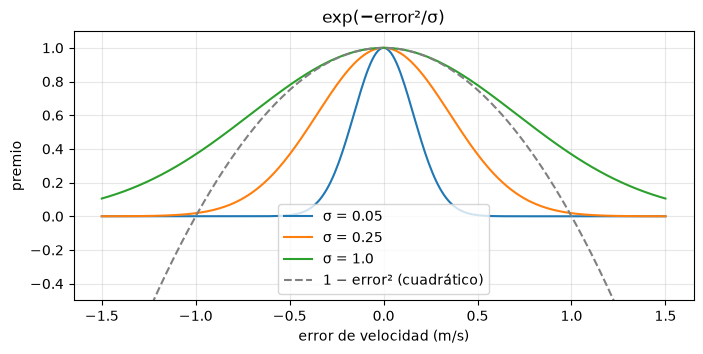

In [15]:
error = np.linspace(-1.5, 1.5, 301)
fig, ax = plt.subplots(figsize=(8, 3.5))
for sigma in [0.05, 0.25, 1.0]:
    ax.plot(error, np.exp(-error ** 2 / sigma), label=f"σ = {sigma}")
ax.plot(error, 1 - error ** 2, "--", color="gray", label="1 − error² (cuadrático)")
ax.set(xlabel="error de velocidad (m/s)", ylabel="premio", ylim=(-0.5, 1.1), title="exp(−error²/σ)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Con σ pequeño, la campana es estrecha y exigente: o lo haces casi perfecto, o no hay premio (y al principio, cuando la red no sabe nada, **nunca** hay premio: no aprende). Con σ grande, todo vale más o menos igual: no hay incentivo para afinar. σ = 0,25 es el valor de legged_gym, para órdenes de este tamaño.

### La trampa: quedarse quieto

Haz la cuenta para una orden de 0,5 m/s. Si el robot se queda **de pie, sin moverse**, el error es 0,5, y el premio de seguimiento es exp(−0,25/0,25) = **0,37**. ¡Un 37 % del máximo, sin hacer nada! Y quedarse quieto es fácil y seguro, mientras que intentar andar es difícil y, al principio, acaba en el suelo (y sin premio el resto del episodio). Es un **óptimo local** de libro (NB17): una colina pequeña de la que a la red le cuesta salir. Vamos a tenerlo muy presente al mirar los entrenamientos.

### Muchos términos, cada uno con su peso

La recompensa de legged_gym no es un solo término: es una **suma de muchos** pequeños, cada uno con su **peso** (NB44 ya lo hizo a mano). Los nuestros:

| Término | Qué mide | Peso | Por qué |
|---|---|---|---|
| `seguir_velocidad` | exp(−\|orden_xy − v_xy\|²/σ) | +1,0 | **la tarea** |
| `seguir_giro` | exp(−(orden_giro − ω_z)²/σ) | +1,0 | la tarea (girar) |
| `avance` | avance en la dirección de la orden, en fracción de lo pedido (−1 a 1) | +1,0 | pistas "desde lejos" (sección 10) |
| `vivo` | 1 en cada paso | +0,15 | un empujoncito para no caerse |
| `contacto_fase` | pies que apoyan cuando dice el reloj (0, 1 o 2) | +0,5 | ayuda a que aparezca una marcha alterna |
| `pie_en_el_aire` | al aterrizar: tiempo en el aire − 0,3 s | +2,0 | pasos de verdad, no arrastrar los pies |
| `velocidad_vertical` | v_z² | −2,0 | no botar |
| `balanceo` | ω_x² + ω_y² | −0,05 | no cabecear ni bambolearse |
| `orientacion` | g_x² + g_y² (gravedad proyectada) | −1,0 | torso derecho |
| `altura` | (altura − 0,75)² | −10 | no agacharse hasta el suelo |
| `par` | Σ par² | −0,00001 | gastar poca energía (NB38b) |
| `accion_brusca` | Σ (acción − acción anterior)² | −0,01 | movimientos suaves (motores reales, NB44) |
| `caderas` | giro y alabeo de cadera² | −1,0 | no abrir ni girar las piernas sin motivo |

Casi todos son los de legged_gym y de las políticas de Unitree para sus humanoides, con sus mismos pesos. Cuatro no: `avance` (que no está en ninguno de los dos) y los pesos de `seguir_giro`, `contacto_fase` y `pie_en_el_aire`. Por qué, lo cuenta la sección 10: es la parte más instructiva del notebook.

Cada término se multiplica por su peso **y por dt** (0,02 s), como en legged_gym: así, la recompensa de un episodio no cambia si cambias la decimación (sería la "integral" en el tiempo, NB16).

### El diseño profesional: un registro de términos

En el NB44, la recompensa era una fórmula larga dentro de `step`. Cada vez que querías probar algo, había que tocar el entorno. La forma profesional:

1. Cada término es una **función pequeña**, con su nombre, que recibe las medidas del paso y devuelve un número.
2. Las funciones se apuntan en un **registro**: un diccionario {nombre: función}. Para apuntarlas, un **decorador** (NB49).
3. Los **pesos** están en la **configuración** (un diccionario {nombre: peso}), no en el código. Cambiar un peso, quitar un término (peso 0) o probar variantes no toca el código.
4. Cada término se **registra por separado** durante el entrenamiento. Cuando algo va mal (y en RL, algo va siempre mal), es lo primero que miras: ¿qué término está ganando? ¿cuál se ha comido a los demás? Es como se detecta un *reward hacking* (NB44).

Así se ve en pequeño (en el paquete está completo). El decorador `termino("nombre")` devuelve una función que apunta la función decorada en el registro y la devuelve **sin cambiarla**:


In [16]:
REGISTRO = {}

def termino(nombre):
    def apuntar(funcion):
        REGISTRO[nombre] = funcion
        return funcion
    return apuntar

@termino("seguir_velocidad")
def seguir_velocidad(medidas, sigma=0.25):
    return math.exp(-np.sum((medidas["orden"][:2] - medidas["v"][:2]) ** 2) / sigma)

@termino("orientacion")
def orientacion(medidas):
    return float(np.sum(medidas["gravedad"][:2] ** 2))

print(REGISTRO)

{'seguir_velocidad': <function seguir_velocidad at 0x7ffeb35c5300>, 'orientacion': <function orientacion at 0x7ffeb35c51c0>}


Las dos funciones están en el registro, por su nombre. Ahora, la recompensa total es un bucle sobre los **pesos de la configuración**, que guarda cada parte por separado:


In [17]:
PESOS = {"seguir_velocidad": 1.0, "orientacion": -1.0}

def recompensa(medidas, pesos, dt=0.02):
    partes = {nombre: peso * REGISTRO[nombre](medidas) * dt for nombre, peso in pesos.items()}
    return sum(partes.values()), partes

quieto = {"orden": np.array([0.5, 0, 0]), "v": np.zeros(3), "gravedad": np.array([0.1, 0, -0.995])}
total, partes = recompensa(quieto, PESOS)
print(f"total {total:.5f}   por partes: {partes}")

total 0.00716   por partes: {'seguir_velocidad': 0.007357588823428847, 'orientacion': -0.00020000000000000004}


Un robot quieto (orden de 0,5 m/s) y un poco inclinado: 0,37 de seguimiento × 0,02 = 0,0074, menos 0,01 × 0,02 de inclinación. Y lo más importante: sabemos **de dónde sale** cada trocito. Añadir un término nuevo es escribir una función con su decorador y darle un peso: no se toca nada más.

### Pies en el aire y contacto con fase

Dos términos merecen una explicación:

- **`pie_en_el_aire`** (de legged_gym): cada pie lleva un cronómetro que corre mientras está en el aire. En el instante en que **aterriza**, se premia (tiempo en el aire − 0,3 s). Si el pie estuvo 0,4 s en el aire, +0,1; si solo se despegó un instante (arrastrando los pies, o temblando), un castigo. Empuja a dar **pasos de verdad**. Con la orden "quieto", se apaga.
- **`contacto_fase`** (de las políticas de Unitree): durante la primera mitad de cada vuelta del reloj, el pie derecho debería apoyar y el izquierdo estar en el aire; en la segunda mitad, al revés (con un poco de apoyo doble en el cambio). Se premia cada pie que hace lo que dice el reloj. Con la orden "quieto", lo que se premia es tener los dos pies en el suelo. Es un empujón muy fuerte hacia una marcha **alterna** y rítmica.

Los dos necesitan saber si cada pie está **en el suelo**. Lo sabemos por los **sensores de tacto** del NB53 (`tacto_d`, `tacto_i`): si la planta nota más de 1 N, el pie apoya.

## 6 · El principio y el fin de un episodio

### Terminado y truncado

Gymnasium distingue dos formas de acabar un episodio (NB25, NB33), y confundirlas es un fallo clásico:

- **Terminado** (*terminated*): el episodio acaba **por algo que pasa en el mundo**: Zancudo se ha caído (torso por debajo de 0,45 m, o inclinado más de 1 rad, unos 57°). Después de caerse no hay más recompensa: el valor del futuro es **0**.
- **Truncado** (*truncated*): el episodio acaba **porque se ha acabado el tiempo** (10 s = 500 decisiones). Pero el robot sigue de pie: si el episodio continuara, seguiría ganando recompensa. El valor del futuro **no** es 0; PPO lo estima con el crítico (NB30).

Si marcaras el fin del tiempo como "terminado", el crítico aprendería que estar de pie a los 9,98 s **no vale nada**, y la política se volvería descuidada al final de cada episodio. SB3 lo trata bien si el entorno separa las dos cosas, y el nuestro lo hace.

Una tercera forma de terminar, por seguridad: si la simulación da `NaN` (NB49), terminamos el episodio y lo **avisamos** en el registro. Mejor un aviso que un entrenamiento que muere a las 3 horas.

### Reiniciar con ruido

Cada episodio empieza en la postura por defecto, pero con un poco de **ruido**: ±0,05 rad en cada articulación y ±0,1 en cada velocidad. Si empezara siempre exactamente igual, la red podría aprender una secuencia de movimientos "de memoria" que solo funciona desde ahí. Con ruido, tiene que aprender a **reaccionar**. (En el NB55 llevaremos esta idea mucho más lejos: aleatorizar masas, rozamientos, empujones...)

### Semillas

Todo el azar del entorno (la orden, el ruido) sale de `self.np_random`, el generador que Gymnasium crea al llamar a `reset(seed=...)` (NB25, NB28). La consecuencia: **con la misma semilla, el mismo episodio, bit a bit**. Es lo que permite repetir un resultado, encontrar un fallo, o comparar dos políticas en igualdad de condiciones. Lo comprobaremos con una prueba automática.


## 7 · Python: de notebook a paquete instalable

### Por qué un paquete

En el NB52 escribimos la librería `andar/` dentro de la carpeta `notebooks/`, y la importábamos porque el notebook **estaba en esa misma carpeta**. Funciona, pero tiene límites: desde otra carpeta (un script, una prueba, Colab...) no se encuentra; no dice qué otras librerías necesita; no tiene versión; no tiene una orden para usarla desde la terminal.

Un proyecto profesional de RL (legged_gym, Isaac Lab, MuJoCo Playground...) es un **paquete instalable**: una carpeta con una estructura conocida y un fichero, **`pyproject.toml`**, que le dice a `pip` cómo instalarlo. Una vez instalado, `import locomocion` funciona **desde cualquier sitio** con ese Python, igual que `import numpy`.

### La estructura

Lo pondremos en una carpeta nueva del repositorio, **fuera** de `notebooks/`, porque ya no es "material de un notebook": es un proyecto con vida propia.

```
paquetes/locomocion/               ← el PROYECTO
├── pyproject.toml                 ← la ficha: nombre, versión, dependencias, órdenes
├── src/
│   └── locomocion/                ← el PAQUETE (lo que se importa)
│       ├── __init__.py            ← la puerta: versión, interfaz pública, registro en Gymnasium
│       ├── __main__.py            ← para poder hacer «python -m locomocion»
│       ├── config.py              ← la configuración (dataclasses + YAML, NB53)
│       ├── modelo.py              ← cargar el robot y ajustarlo
│       ├── recompensas.py         ← los términos de la recompensa y su registro
│       ├── entorno.py             ← el entorno de Gymnasium
│       ├── entrenamiento.py       ← entrenar con PPO y evaluar
│       ├── cli.py                 ← la línea de órdenes
│       └── robots/
│           └── zancudo3d.xml      ← un DATO del paquete: viaja con él
└── tests/
    ├── conftest.py                ← fixtures compartidas
    ├── test_config.py
    └── test_entorno.py
```

Dos decisiones que merecen explicación:

- **La carpeta `src/`** (*src layout*). El paquete no está directamente en `paquetes/locomocion/locomocion/`, sino un nivel más abajo. Parece un capricho, pero evita una trampa muy real: si el paquete estuviera junto a las pruebas, al ejecutar las pruebas Python podría importar **la carpeta que tienes delante** en vez del paquete **instalado**, y tus pruebas pasarían en tu ordenador... y fallarían en el de otro, porque te olvidaste de declarar un fichero. Con `src/`, la única forma de importar el paquete es **instalarlo**. Es la estructura que recomienda la guía oficial de empaquetado de Python.
- **El robot va dentro del paquete**, como un fichero de datos. Así, el paquete instalado lleva su robot consigo y lo encuentra esté donde esté (en la sección 7.3 vemos cómo).

Toda la fuente del paquete se escribe desde este notebook con `%%writefile` (NB52). Primero, las carpetas:


In [18]:
PAQUETE = Path("../paquetes/locomocion")
for carpeta in ["src/locomocion/robots", "tests"]:
    (PAQUETE / carpeta).mkdir(parents=True, exist_ok=True)
print("proyecto en:", PAQUETE.resolve())

proyecto en: /home/gregori/dev/robotica/paquetes/locomocion


### 7.1 · `pyproject.toml`: la ficha del proyecto

El formato es **TOML** (*Tom's Obvious Minimal Language*), otro formato de configuración, primo de YAML: secciones entre corchetes, `clave = valor`, textos siempre entre comillas (así no tiene las trampas de adivinar tipos de YAML, NB53):


In [19]:
%%writefile ../paquetes/locomocion/pyproject.toml
[build-system]
requires = ["setuptools>=64"]
build-backend = "setuptools.build_meta"

[project]
name = "locomocion"
version = "0.1.0"
description = "Entorno de locomoción 3D de Zancudo para aprendizaje por refuerzo (curso de robótica, NB54)"
requires-python = ">=3.10"
dependencies = [
    "mujoco>=3.1",
    "gymnasium>=1.0",
    "numpy",
    "pyyaml",
]

[project.optional-dependencies]
entrenar = ["stable-baselines3>=2.3", "torch"]
pruebas = ["pytest"]

[project.scripts]
locomocion = "locomocion.cli:main"

[tool.setuptools.packages.find]
where = ["src"]

[tool.setuptools.package-data]
locomocion = ["robots/*.xml"]

[tool.pytest.ini_options]
testpaths = ["tests"]

Overwriting ../paquetes/locomocion/pyproject.toml


Sección a sección:

- **`[build-system]`**: con qué herramienta se construye el paquete. Usamos **setuptools**, la clásica (otras: hatchling, poetry, flit...). `pip` la lee primero.
- **`[project]`**: la ficha. Nombre, **versión** (0.1.0: la primera, todavía inestable, siguiendo el *versionado semántico*: MAYOR.MENOR.PARCHE), descripción, versión mínima de Python y **dependencias**: lo que tiene que estar instalado para que el paquete funcione. Al instalarlo, `pip` las instalaría si faltasen.
- **`[project.optional-dependencies]`**: dependencias **opcionales**, por grupos. Para usar el entorno no hace falta SB3 ni PyTorch (alguien podría entrenarlo con otra librería); para **entrenar** con nuestro código, sí. Se instalan pidiéndolas: `pip install locomocion[entrenar]`.
- **`[project.scripts]`**: crea una **orden de la terminal** llamada `locomocion` que ejecuta la función `main` del módulo `locomocion.cli`. La veremos en la sección 8.
- **`[tool.setuptools...]`**: dónde están los paquetes (en `src/`) y qué **ficheros de datos** incluir (los `.xml` de `robots/`; si no se declaran, ¡no se instalan!).
- **`[tool.pytest.ini_options]`**: dónde busca pytest las pruebas. Muchas herramientas (pytest, mypy, ruff, black...) leen su configuración de este mismo fichero: un solo sitio para todo.

### 7.2 · Los módulos

Ahora el código. Es lo de las secciones 2 a 6, **ordenado**: con tipos, *docstrings* y sin variables globales (las reglas del NB52). Primero, **`config.py`**: la configuración del entorno con las dataclasses del NB53:


In [20]:
%%writefile ../paquetes/locomocion/src/locomocion/config.py
"""Configuración del entorno: dataclasses congeladas + YAML + cambios desde la línea de órdenes."""
from __future__ import annotations

import dataclasses
import difflib
import typing
from dataclasses import dataclass, field
from pathlib import Path

import yaml


@dataclass(frozen=True)
class Simulacion:
    paso: float = 0.005          # s: el paso de la física (timestep de MuJoCo)
    decimacion: int = 4          # pasos de física por cada decisión de la política
    kp: float = 300.0            # rigidez de los servos (N·m/rad)
    kv: float = 10.0             # amortiguación de los servos (N·m·s/rad)
    escala_accion: float = 0.3   # rad: cuánto se aparta el objetivo de la postura por defecto con acción ±1

    def __post_init__(self):
        if self.paso <= 0 or self.decimacion < 1 or self.kp <= 0 or self.kv < 0 or self.escala_accion <= 0:
            raise ValueError(f"Simulacion: valores fuera de rango ({self})")

    @property
    def dt(self) -> float:
        """Tiempo entre dos decisiones de la política."""
        return self.paso * self.decimacion


@dataclass(frozen=True)
class Comandos:
    vx: tuple[float, float] = (-0.3, 0.6)       # m/s, hacia delante (en el marco del torso)
    vy: tuple[float, float] = (-0.2, 0.2)       # m/s, de lado
    giro: tuple[float, float] = (-0.5, 0.5)     # rad/s, alrededor del eje vertical
    prob_quieto: float = 0.1                     # fracción de episodios con la orden «quieto»

    def __post_init__(self):
        for nombre in ("vx", "vy", "giro"):
            bajo, alto = getattr(self, nombre)
            if bajo > alto:
                raise ValueError(f"Comandos.{nombre}: el mínimo ({bajo}) es mayor que el máximo ({alto})")
        if not 0.0 <= self.prob_quieto <= 1.0:
            raise ValueError("Comandos.prob_quieto debe estar entre 0 y 1")


PESOS_POR_DEFECTO = {
    "seguir_velocidad": 1.0,
    "seguir_giro": 1.0,
    "avance": 1.0,
    "vivo": 0.15,
    "contacto_fase": 0.5,
    "pie_en_el_aire": 2.0,
    "velocidad_vertical": -2.0,
    "balanceo": -0.05,
    "orientacion": -1.0,
    "altura": -10.0,
    "par": -1e-5,
    "accion_brusca": -0.01,
    "caderas": -1.0,
}


@dataclass(frozen=True)
class Recompensa:
    pesos: dict[str, float] = field(default_factory=lambda: dict(PESOS_POR_DEFECTO))
    sigma: float = 0.25              # anchura de la campana exp(−error²/σ)
    altura_objetivo: float = 0.75    # m: altura del torso que se premia
    periodo_paso: float = 0.8        # s: una vuelta del reloj de fase = dos pasos
    aire_objetivo: float = 0.3       # s: tiempo de pie en el aire que se premia

    def __post_init__(self):
        if self.sigma <= 0 or self.periodo_paso <= 0:
            raise ValueError("Recompensa: sigma y periodo_paso deben ser positivos")


@dataclass(frozen=True)
class Episodio:
    duracion: float = 10.0           # s
    altura_minima: float = 0.45      # m: por debajo, se ha caído
    inclinacion_maxima: float = 1.0  # rad: más inclinado, se ha caído
    ruido_articulaciones: float = 0.05   # rad: ruido de la postura inicial
    ruido_velocidades: float = 0.1       # rad/s y m/s: ruido de las velocidades iniciales

    def __post_init__(self):
        if self.duracion <= 0 or self.ruido_articulaciones < 0 or self.ruido_velocidades < 0:
            raise ValueError(f"Episodio: valores fuera de rango ({self})")


@dataclass(frozen=True)
class ConfigEntorno:
    nombre: str = "zancudo3d_andar"
    simulacion: Simulacion = field(default_factory=Simulacion)
    comandos: Comandos = field(default_factory=Comandos)
    recompensa: Recompensa = field(default_factory=Recompensa)
    episodio: Episodio = field(default_factory=Episodio)


# --------------------------------------------------------------------------------------------
# De diccionario (YAML) a dataclass, comprobando claves y tipos (la versión del NB53, ampliada
# con tuplas y diccionarios).

def _convertir(tipo, valor, donde: str):
    origen = typing.get_origin(tipo)
    if dataclasses.is_dataclass(tipo):
        return desde_dict(tipo, valor)
    if origen is tuple:
        if not isinstance(valor, (list, tuple)) or len(valor) != len(typing.get_args(tipo)):
            raise TypeError(f"{donde}: esperaba una lista de {len(typing.get_args(tipo))} números, llegó {valor!r}")
        return tuple(_convertir(t, v, donde) for t, v in zip(typing.get_args(tipo), valor))
    if origen is dict:
        if not isinstance(valor, dict):
            raise TypeError(f"{donde}: esperaba un diccionario, llegó {valor!r}")
        _, tipo_valor = typing.get_args(tipo)
        return {str(k): _convertir(tipo_valor, v, f"{donde}.{k}") for k, v in valor.items()}
    if tipo is float and isinstance(valor, int) and not isinstance(valor, bool):
        return float(valor)
    if not isinstance(valor, tipo) or isinstance(valor, bool) != (tipo is bool):
        raise TypeError(f"{donde}: esperaba {tipo.__name__}, llegó {valor!r} ({type(valor).__name__})")
    return valor


def desde_dict(clase, datos: dict):
    """Crea una dataclass (anidada) a partir de un diccionario, comprobando claves y tipos."""
    if not isinstance(datos, dict):
        raise TypeError(f"{clase.__name__}: esperaba un diccionario, llegó {type(datos).__name__}")
    tipos = typing.get_type_hints(clase)
    validos = {f.name for f in dataclasses.fields(clase)}
    for clave in datos:
        if clave not in validos:
            parecidas = difflib.get_close_matches(clave, validos, n=1)
            pista = f" ¿Querías decir '{parecidas[0]}'?" if parecidas else ""
            raise KeyError(f"{clase.__name__}: clave desconocida '{clave}'.{pista}")
    valores = {clave: _convertir(tipos[clave], valor, f"{clase.__name__}.{clave}") for clave, valor in datos.items()}
    return clase(**valores)


def fusionar(base: dict, cambios: dict) -> dict:
    """Copia de base con los cambios aplicados, entrando en los diccionarios anidados (NB53)."""
    resultado = dict(base)
    for clave, valor in cambios.items():
        if isinstance(valor, dict) and isinstance(resultado.get(clave), dict):
            resultado[clave] = fusionar(resultado[clave], valor)
        else:
            resultado[clave] = valor
    return resultado


def cambio_desde_texto(texto: str) -> dict:
    """'simulacion.kp=200' → {'simulacion': {'kp': 200}}. El valor se lee como YAML (¡con sus trampas!)."""
    if "=" not in texto:
        raise ValueError(f"cambio mal escrito: '{texto}' (forma: seccion.clave=valor)")
    ruta, valor = texto.split("=", 1)
    resultado: dict = yaml.safe_load(valor)
    for clave in reversed(ruta.strip().split(".")):
        resultado = {clave: resultado}
    return resultado


def a_dict(cfg: ConfigEntorno) -> dict:
    """La configuración como diccionario de tipos básicos (las tuplas, como listas), listo para YAML."""
    def limpiar(x):
        if isinstance(x, dict):
            return {k: limpiar(v) for k, v in x.items()}
        if isinstance(x, (list, tuple)):
            return [limpiar(v) for v in x]
        return x
    return limpiar(dataclasses.asdict(cfg))


def cargar_config(ruta: str | Path | None = None, cambios: list[str] | None = None) -> ConfigEntorno:
    """Configuración por defecto ← fichero YAML (opcional) ← cambios 'a.b=valor' (opcionales)."""
    datos = a_dict(ConfigEntorno())
    if ruta is not None:
        datos = fusionar(datos, yaml.safe_load(Path(ruta).read_text(encoding="utf-8")) or {})
    for cambio in cambios or []:
        datos = fusionar(datos, cambio_desde_texto(cambio))
    return desde_dict(ConfigEntorno, datos)


def guardar_config(cfg: ConfigEntorno, ruta: str | Path) -> None:
    Path(ruta).write_text(yaml.safe_dump(a_dict(cfg), sort_keys=False, allow_unicode=True), encoding="utf-8")

Overwriting ../paquetes/locomocion/src/locomocion/config.py


Lo que hay que mirar:

- **Cinco secciones**, cada una con su dataclass congelada y su validación: `Simulacion` (paso, decimación, servos, escala de la acción), `Comandos` (los rangos de las órdenes), `Recompensa` (los **pesos**, en un diccionario, y σ, la altura, el periodo del reloj...), `Episodio` (duración, condiciones de caída, ruido del reinicio) y la principal, `ConfigEntorno`.
- **`@property dt`** en `Simulacion`: el tiempo entre decisiones, **calculado** (paso × decimación), no guardado. Si fuera un campo más, alguien podría cambiar el paso y olvidarse de cambiar `dt`, y tendríamos dos números que se contradicen. Lo que se puede calcular, no se guarda.
- **`desde_dict`** es la del NB53, ampliada: ahora sabe convertir **tuplas** (YAML no tiene tuplas: las guarda como listas) y **diccionarios** (los pesos). Para eso mira el tipo anotado con **`typing.get_origin`**: para `tuple[float, float]` devuelve `tuple`, y **`typing.get_args`** devuelve `(float, float)`.
- **`cambio_desde_texto("simulacion.kp=200")`** → `{"simulacion": {"kp": 200}}`: la forma de Hydra de cambiar un valor desde la terminal, que prometimos en el NB53. El valor se lee con `yaml.safe_load`, así que `200` es un número, `true` un booleano y `[0, 1]` una lista... **y `1e-3` un texto** (la trampa de YAML 1.1, NB53). Lo veremos en acción.
- **`cargar_config`**: por defecto ← fichero YAML ← cambios. Tres capas, fusionadas en profundidad (NB53). Es exactamente cómo funcionan los ficheros de configuración de Isaac Lab o MuJoCo Playground.

**`modelo.py`**, que carga el robot:


In [21]:
%%writefile ../paquetes/locomocion/src/locomocion/modelo.py
"""El robot: cargar Zancudo 3D (dato del paquete) y ajustarlo a la configuración."""
from __future__ import annotations

import logging
from importlib import resources

import mujoco
import numpy as np

from .config import Simulacion

logger = logging.getLogger(__name__)

ARCHIVO_ROBOT = "zancudo3d.xml"


def ruta_robot() -> str:
    """Ruta del MJCF que viaja DENTRO del paquete (funciona esté donde esté instalado)."""
    return str(resources.files("locomocion") / "robots" / ARCHIVO_ROBOT)


def cargar_modelo(sim: Simulacion) -> mujoco.MjModel:
    """Carga el MJCF y le aplica el paso de tiempo y la rigidez de los servos de la configuración."""
    modelo = mujoco.MjModel.from_xml_path(ruta_robot())
    modelo.opt.timestep = sim.paso
    # servos de posición (NB50): fuerza = kp·(ctrl − q) − kv·q̇  →  gainprm[0] = kp, biasprm[1:3] = (−kp, −kv)
    modelo.actuator_gainprm[:, 0] = sim.kp
    modelo.actuator_biasprm[:, 1] = -sim.kp
    modelo.actuator_biasprm[:, 2] = -sim.kv
    logger.debug("modelo cargado: nq=%d nv=%d nu=%d, paso %.4f s, kp=%.0f kv=%.1f",
                 modelo.nq, modelo.nv, modelo.nu, sim.paso, sim.kp, sim.kv)
    return modelo


class Indices:
    """Dónde está cada cosa del robot (se calcula UNA vez, no en cada paso)."""

    def __init__(self, modelo: mujoco.MjModel):
        self.torso = modelo.body("torso").id
        self.pies = np.array([modelo.body("pie_d").id, modelo.body("pie_i").id])
        self.tactos = [modelo.sensor("tacto_d").adr[0], modelo.sensor("tacto_i").adr[0]]
        self.postura_defecto = modelo.key("agachado").qpos[7:].copy()
        self.qpos_inicial = modelo.key("agachado").qpos.copy()
        self.limite_bajo = modelo.actuator_ctrlrange[:, 0].copy()
        self.limite_alto = modelo.actuator_ctrlrange[:, 1].copy()

Overwriting ../paquetes/locomocion/src/locomocion/modelo.py


- **`importlib.resources.files("locomocion")`** devuelve la carpeta donde está **instalado** el paquete, esté donde esté: en tu `venv`, en Colab, en el ordenador de otra persona. Con una ruta como `"robots/zancudo3d.xml"` dependeríamos de la carpeta desde la que se ejecuta el programa (NB26), y fallaría en cuanto alguien lo usara desde otra.
- **`Indices`**: los identificadores y posiciones del robot, calculados **una vez** al crear el entorno. Buscar por nombre (`modelo.body("torso")`) en cada paso, 50 veces por segundo y por 16 entornos, sería tirar el tiempo.

Copiamos al paquete el robot del NB53:


In [22]:
import shutil
shutil.copy("robots/zancudo3d.xml", PAQUETE / "src/locomocion/robots/zancudo3d.xml")
print(sorted(p.name for p in (PAQUETE / "src/locomocion/robots").iterdir()))

['zancudo3d.xml']


**`recompensas.py`**, el registro de términos de la sección 5, completo:


In [23]:
%%writefile ../paquetes/locomocion/src/locomocion/recompensas.py
"""Recompensa modular: cada término es una función pequeña, registrada con un nombre.

La recompensa total = Σ peso[nombre] · término[nombre] · dt. Los pesos viven en la configuración.
"""
from __future__ import annotations

import difflib
from dataclasses import dataclass
from typing import Callable

import numpy as np

from .config import Recompensa


@dataclass
class Medidas:
    """Todo lo que los términos necesitan saber de un paso (se calcula una vez y se comparte)."""
    comando: np.ndarray            # (vx, vy, giro) pedidos
    vel_lineal: np.ndarray         # velocidad del torso en SU marco (3)
    vel_angular: np.ndarray        # velocidad angular del torso en su marco (3)
    gravedad: np.ndarray           # gravedad proyectada en el marco del torso (3)
    altura: float                  # altura del torso (m)
    pares: np.ndarray              # pares de los motores (12)
    accion: np.ndarray             # acción de este paso (12)
    accion_anterior: np.ndarray    # acción del paso anterior (12)
    articulaciones: np.ndarray     # ángulos relativos a la postura por defecto (12)
    contacto: np.ndarray           # ¿pie en el suelo? (2, bool)
    primer_contacto: np.ndarray    # ¿acaba de aterrizar? (2, bool)
    tiempo_aire: np.ndarray        # cuánto llevaba en el aire al aterrizar (2, s)
    fase: float                    # reloj de la marcha, de 0 a 1


Termino = Callable[[Medidas, Recompensa], float]
TERMINOS: dict[str, Termino] = {}


def termino(nombre: str) -> Callable[[Termino], Termino]:
    """Decorador que registra una función como término de la recompensa."""
    def registrar(funcion: Termino) -> Termino:
        if nombre in TERMINOS:
            raise ValueError(f"término repetido: {nombre}")
        TERMINOS[nombre] = funcion
        return funcion
    return registrar


# --- lo que se premia ------------------------------------------------------------------------
@termino("seguir_velocidad")
def _seguir_velocidad(m: Medidas, cfg: Recompensa) -> float:
    error = np.sum((m.comando[:2] - m.vel_lineal[:2]) ** 2)
    return float(np.exp(-error / cfg.sigma))


@termino("seguir_giro")
def _seguir_giro(m: Medidas, cfg: Recompensa) -> float:
    return float(np.exp(-(m.comando[2] - m.vel_angular[2]) ** 2 / cfg.sigma))


@termino("vivo")
def _vivo(m: Medidas, cfg: Recompensa) -> float:
    return 1.0


@termino("avance")
def _avance(m: Medidas, cfg: Recompensa) -> float:
    """Cuánto se avanza EN LA DIRECCIÓN de la orden, en fracción de lo pedido (de −1 a 1)."""
    pedida = m.comando[:2]
    rapidez = float(np.linalg.norm(pedida))
    if rapidez < 0.1:
        return 0.0
    hacia = float(np.dot(m.vel_lineal[:2], pedida)) / rapidez        # proyección sobre la dirección pedida
    return float(np.clip(hacia / rapidez, -1.0, 1.0))


@termino("contacto_fase")
def _contacto_fase(m: Medidas, cfg: Recompensa) -> float:
    """+1 por cada pie que está donde dice el reloj: derecho apoyado en la 1.ª mitad, izquierdo en la 2.ª."""
    if np.linalg.norm(m.comando) < 0.1:
        return float(np.sum(m.contacto))                      # orden «quieto»: los dos pies en el suelo
    debe_apoyar = np.array([m.fase < 0.55, m.fase >= 0.45])   # un poco de apoyo doble
    return float(np.sum(m.contacto == debe_apoyar))


@termino("pie_en_el_aire")
def _pie_en_el_aire(m: Medidas, cfg: Recompensa) -> float:
    """Al aterrizar: premio si el pie ha estado en el aire más que aire_objetivo (pasos de verdad)."""
    if np.linalg.norm(m.comando[:2]) < 0.1:
        return 0.0
    return float(np.sum((m.tiempo_aire - cfg.aire_objetivo) * m.primer_contacto))


# --- lo que se castiga (pesos negativos) -------------------------------------------------------
@termino("velocidad_vertical")
def _velocidad_vertical(m: Medidas, cfg: Recompensa) -> float:
    return float(m.vel_lineal[2] ** 2)


@termino("balanceo")
def _balanceo(m: Medidas, cfg: Recompensa) -> float:
    return float(np.sum(m.vel_angular[:2] ** 2))


@termino("orientacion")
def _orientacion(m: Medidas, cfg: Recompensa) -> float:
    return float(np.sum(m.gravedad[:2] ** 2))


@termino("altura")
def _altura(m: Medidas, cfg: Recompensa) -> float:
    return float((m.altura - cfg.altura_objetivo) ** 2)


@termino("par")
def _par(m: Medidas, cfg: Recompensa) -> float:
    return float(np.sum(m.pares ** 2))


@termino("accion_brusca")
def _accion_brusca(m: Medidas, cfg: Recompensa) -> float:
    return float(np.sum((m.accion - m.accion_anterior) ** 2))


CADERAS_GIRO_LADO = [0, 1, 6, 7]   # cadera_giro y cadera_lado de las dos piernas


@termino("caderas")
def _caderas(m: Medidas, cfg: Recompensa) -> float:
    return float(np.sum(m.articulaciones[CADERAS_GIRO_LADO] ** 2))


# ----------------------------------------------------------------------------------------------
def comprobar_pesos(pesos: dict[str, float]) -> None:
    """Error claro si la configuración nombra un término que no existe (con pista si es una errata)."""
    for nombre in pesos:
        if nombre not in TERMINOS:
            parecidas = difflib.get_close_matches(nombre, TERMINOS, n=1)
            pista = f" ¿Querías decir '{parecidas[0]}'?" if parecidas else ""
            raise KeyError(f"término de recompensa desconocido: '{nombre}'.{pista}")


def calcular(m: Medidas, cfg: Recompensa, dt: float) -> tuple[float, dict[str, float]]:
    """Recompensa total y cada término por separado (ya multiplicado por su peso y por dt)."""
    partes = {nombre: peso * TERMINOS[nombre](m, cfg) * dt for nombre, peso in cfg.pesos.items() if peso != 0.0}
    return sum(partes.values()), partes

Overwriting ../paquetes/locomocion/src/locomocion/recompensas.py


- **`Medidas`**: una dataclass con todo lo que los términos pueden necesitar. El entorno la rellena **una vez** por paso y se la pasa a todos los términos. Así, cada término es una función pura (P2): recibe datos, devuelve un número, no toca nada. Fácil de probar y de entender.
- **`Termino = Callable[[Medidas, Recompensa], float]`**: un **alias de tipo** (P5): "una función que recibe unas medidas y la configuración de la recompensa, y devuelve un número". Documenta qué forma tiene que tener un término.
- **`termino(nombre)`** es el decorador, ahora con una defensa: si dos términos se registran con el mismo nombre, error (el segundo machacaría al primero sin avisar).
- Las funciones de los términos empiezan por `_`: nadie debería llamarlas directamente; se usan **a través del registro**.
- **`comprobar_pesos`** avisa si la configuración nombra un término que no existe, con pista (`difflib`, NB53). Sin esto, una errata en un peso (`velocida_vertical: -2.0`) haría que ese término **no se usara**, en silencio: entrenarías 3 horas sin él.
- **`calcular`** salta los términos con peso 0 (para no gastar tiempo) y devuelve el total **y** las partes.

**`entorno.py`**, el corazón:


In [24]:
%%writefile ../paquetes/locomocion/src/locomocion/entorno.py
"""El entorno de Gymnasium: Zancudo 3D tiene que seguir órdenes de velocidad (vx, vy, giro)."""
from __future__ import annotations

import logging

import gymnasium as gym
import mujoco
import numpy as np
from gymnasium import spaces

from . import recompensas
from .config import ConfigEntorno
from .modelo import Indices, cargar_modelo

logger = logging.getLogger(__name__)

# escalas de la observación: que todos los números anden por ±1 (como legged_gym)
ESCALA_VEL_LINEAL = 2.0
ESCALA_VEL_ANGULAR = 0.25
ESCALA_VEL_ARTICULAR = 0.05
UMBRAL_CONTACTO = 1.0          # N: con más fuerza en la planta, el pie «está en el suelo»
DIM_OBS = 3 + 3 + 3 + 3 + 12 + 12 + 12 + 2


class ZancudoLocomocion(gym.Env):
    """Zancudo 3D con órdenes de velocidad.

    Observación (50 números, todo en el marco del torso, nada de posición absoluta):
      gravedad proyectada (3) · velocidad angular (3) · velocidad lineal (3) · órdenes (3)
      · ángulos − postura por defecto (12) · velocidades articulares (12) · última acción (12)
      · reloj de fase (sen, cos) (2)
    Acción (12 números en ±1): objetivo de los servos = postura por defecto + escala · acción.
    """

    metadata = {"render_modes": ["rgb_array"], "render_fps": 50}

    def __init__(self, config: ConfigEntorno | None = None, render_mode: str | None = None):
        self.config = config or ConfigEntorno()
        recompensas.comprobar_pesos(self.config.recompensa.pesos)
        self.modelo = cargar_modelo(self.config.simulacion)
        self.datos = mujoco.MjData(self.modelo)
        self.ind = Indices(self.modelo)
        self.dt = self.config.simulacion.dt
        self.max_pasos = round(self.config.episodio.duracion / self.dt)
        self.metadata = {**self.metadata, "render_fps": round(1 / self.dt)}
        self.render_mode = render_mode
        self._camara = None

        self.action_space = spaces.Box(-1.0, 1.0, shape=(self.modelo.nu,), dtype=np.float32)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(DIM_OBS,), dtype=np.float32)

        self.comando = np.zeros(3)
        self.accion = np.zeros(self.modelo.nu)
        self.accion_anterior = np.zeros(self.modelo.nu)
        self.tiempo_aire = np.zeros(2)
        self.contacto_anterior = np.ones(2, dtype=bool)
        self.pasos = 0
        self.terminos_episodio: dict[str, float] = {}

    # --- lo que «siente» el robot -----------------------------------------------------------
    def _rotacion(self) -> np.ndarray:
        return self.datos.xmat[self.ind.torso].reshape(3, 3)

    def _medir(self) -> dict[str, np.ndarray]:
        d, R = self.datos, self._rotacion()
        return {
            "gravedad": R.T @ np.array([0.0, 0.0, -1.0]),         # del mundo al marco del torso (NB53, E1)
            "vel_angular": d.qvel[3:6].copy(),                     # ya está en el marco local (NB53)
            "vel_lineal": R.T @ d.qvel[0:3],                       # la lineal está en el mundo: la giramos
            "articulaciones": d.qpos[7:] - self.ind.postura_defecto,
            "vel_articulares": d.qvel[6:].copy(),
            "contacto": d.sensordata[self.ind.tactos] > UMBRAL_CONTACTO,
        }

    def _fase(self) -> float:
        return (self.pasos * self.dt / self.config.recompensa.periodo_paso) % 1.0

    def _observacion(self, medida: dict[str, np.ndarray]) -> np.ndarray:
        fase = 2 * np.pi * self._fase()
        obs = np.concatenate([
            medida["gravedad"],
            medida["vel_angular"] * ESCALA_VEL_ANGULAR,
            medida["vel_lineal"] * ESCALA_VEL_LINEAL,
            self.comando * np.array([ESCALA_VEL_LINEAL, ESCALA_VEL_LINEAL, ESCALA_VEL_ANGULAR]),
            medida["articulaciones"],
            medida["vel_articulares"] * ESCALA_VEL_ARTICULAR,
            self.accion,
            [np.sin(fase), np.cos(fase)],
        ])
        return obs.astype(np.float32)

    # --- órdenes ----------------------------------------------------------------------------
    def muestrear_comando(self) -> np.ndarray:
        c = self.config.comandos
        if self.np_random.random() < c.prob_quieto:
            return np.zeros(3)
        return np.array([self.np_random.uniform(*c.vx), self.np_random.uniform(*c.vy), self.np_random.uniform(*c.giro)])

    # --- la API de Gymnasium ------------------------------------------------------------------
    def reset(self, *, seed: int | None = None, options: dict | None = None):
        super().reset(seed=seed)                       # siembra self.np_random (NB25, NB28)
        ep, d = self.config.episodio, self.datos
        mujoco.mj_resetData(self.modelo, d)
        d.qpos[:] = self.ind.qpos_inicial
        d.qpos[7:] += self.np_random.uniform(-ep.ruido_articulaciones, ep.ruido_articulaciones, self.modelo.nu)
        d.qvel[:] = self.np_random.uniform(-ep.ruido_velocidades, ep.ruido_velocidades, self.modelo.nv)
        d.ctrl[:] = self.ind.postura_defecto
        mujoco.mj_forward(self.modelo, d)

        opciones = options or {}
        self.comando = np.asarray(opciones["comando"], dtype=float) if "comando" in opciones else self.muestrear_comando()
        self.accion[:] = 0.0
        self.accion_anterior[:] = 0.0
        self.tiempo_aire[:] = 0.0
        self.contacto_anterior[:] = True
        self.pasos = 0
        self.terminos_episodio = {}
        return self._observacion(self._medir()), {"comando": self.comando.copy()}

    def step(self, accion):
        sim, ep = self.config.simulacion, self.config.episodio
        self.accion_anterior = self.accion
        self.accion = np.clip(np.asarray(accion, dtype=float), -1.0, 1.0)
        objetivo = self.ind.postura_defecto + sim.escala_accion * self.accion
        self.datos.ctrl[:] = np.clip(objetivo, self.ind.limite_bajo, self.ind.limite_alto)
        for _ in range(sim.decimacion):                # decimación: varios pasos de física por decisión
            mujoco.mj_step(self.modelo, self.datos)
        self.pasos += 1

        medida = self._medir()
        contacto = medida["contacto"]
        primer_contacto = contacto & ~self.contacto_anterior
        self.tiempo_aire += self.dt
        tiempo_aire_al_aterrizar = self.tiempo_aire * primer_contacto
        self.tiempo_aire[contacto] = 0.0
        self.contacto_anterior = contacto

        altura = float(self.datos.qpos[2])
        m = recompensas.Medidas(
            comando=self.comando, vel_lineal=medida["vel_lineal"], vel_angular=medida["vel_angular"],
            gravedad=medida["gravedad"], altura=altura, pares=self.datos.actuator_force.copy(),
            accion=self.accion, accion_anterior=self.accion_anterior, articulaciones=medida["articulaciones"],
            contacto=contacto, primer_contacto=primer_contacto, tiempo_aire=tiempo_aire_al_aterrizar,
            fase=self._fase(),
        )
        recompensa, partes = recompensas.calcular(m, self.config.recompensa, self.dt)
        for nombre, valor in partes.items():
            self.terminos_episodio[nombre] = self.terminos_episodio.get(nombre, 0.0) + valor

        inclinacion = float(np.arccos(np.clip(-medida["gravedad"][2], -1.0, 1.0)))
        caido = altura < ep.altura_minima or inclinacion > ep.inclinacion_maxima
        sin_numeros = not np.all(np.isfinite(self.datos.qpos))
        terminado = bool(caido or sin_numeros)
        truncado = self.pasos >= self.max_pasos
        if sin_numeros:
            logger.warning("la simulación ha dado NaN en el paso %d: se termina el episodio", self.pasos)

        info = {"terminos": partes, "vel_lineal": medida["vel_lineal"], "vel_angular": medida["vel_angular"],
                "comando": self.comando.copy(), "contacto": contacto}
        if terminado or truncado:
            info["episodio_terminos"] = dict(self.terminos_episodio)
        return self._observacion(medida), float(recompensa), terminado, truncado, info

    def render(self):
        if self._camara is None:
            self._camara = mujoco.Renderer(self.modelo, height=240, width=320)
        self._camara.update_scene(self.datos, camera="lado")
        return self._camara.render()

    def close(self):
        if self._camara is not None:
            self._camara.close()
            self._camara = None

Overwriting ../paquetes/locomocion/src/locomocion/entorno.py


Recorrido rápido, que ya conoces cada pieza:

- **`__init__`**: comprueba los pesos, carga el modelo con la configuración, prepara los índices y los **espacios** (NB25): acción, 12 números en ±1; observación, 50 números en `float32` (lo que usan las redes; NB44p6).
- **`_medir`**: las piezas de la sección 3, en un diccionario. **`_observacion`**: las junta con sus escalas.
- **`reset`**: `super().reset(seed=seed)` siembra `self.np_random` (¡siempre primero!); postura por defecto con ruido; sorteo de la orden. Fíjate en **`options`**: Gymnasium permite pasar opciones al reiniciar, y las usamos para **fijar** la orden en vez de sortearla (`options={"comando": [0.4, 0, 0]}`): imprescindible para evaluar ("¿qué hace con 0,4 m/s?"). El asterisco en `reset(self, *, seed=None, options=None)` obliga a pasar `seed` y `options` **por nombre**, como exige la API de Gymnasium.
- **`step`**: acción → objetivo (recortado) → **4 pasos de física** (la decimación) → medidas → cronómetros de los pies → `Medidas` → recompensa por partes → ¿caído? ¿NaN? ¿fin del tiempo? En `info` van las partes de este paso y, al acabar el episodio, la **suma de cada término en todo el episodio** (`episodio_terminos`), que es lo que registraremos al entrenar.
- Un detalle de los cronómetros de los pies: `primer_contacto = contacto & ~self.contacto_anterior` es "ahora apoya y antes no": el instante del aterrizaje. `&` es el "y" de NumPy para arrays de booleanos, y `~` el "no" (P6).

**`entrenamiento.py`**: entrenar con PPO, evaluar, y una clase para **usar** una política guardada:


In [25]:
%%writefile ../paquetes/locomocion/src/locomocion/entrenamiento.py
"""Entrenar (PPO de Stable-Baselines3) y evaluar políticas de locomoción."""
from __future__ import annotations

import csv
import json
import logging
import time
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np

from .config import ConfigEntorno, guardar_config, cargar_config
from .entorno import ZancudoLocomocion

logger = logging.getLogger(__name__)


@dataclass(frozen=True)
class AjustesPPO:
    """Los hiperparámetros del algoritmo (aparte de los del entorno)."""
    n_entornos: int = 16
    n_pasos: int = 256               # pasos por entorno antes de cada actualización (16 × 256 = 4096)
    lote: int = 1024
    epocas: int = 5
    tasa_aprendizaje: float = 3e-4
    gamma: float = 0.99
    lambda_gae: float = 0.95
    entropia: float = 0.0
    log_std_inicial: float = -1.0
    red: tuple[int, ...] = (256, 128)
    hilos_torch: int = 2


def _fabrica(config: ConfigEntorno):
    def crear():
        return ZancudoLocomocion(config)
    return crear


def crear_entornos(config: ConfigEntorno, n: int, semilla: int, procesos: bool = True):
    """n copias del entorno (en procesos aparte si procesos=True), cada una con su semilla."""
    from stable_baselines3.common.env_util import make_vec_env
    from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv
    clase = SubprocVecEnv if procesos and n > 1 else DummyVecEnv
    return make_vec_env(_fabrica(config), n_envs=n, seed=semilla, vec_env_cls=clase)


def _registro_callback(carpeta: Path, cada_actualizacion: int = 10):
    """Retrollamada de SB3: en cada actualización apunta en progreso.csv la media de cada término por episodio
    (y la cuenta en el registro: con nivel INFO una de cada `cada_actualizacion`, el resto con DEBUG)."""
    from stable_baselines3.common.callbacks import BaseCallback

    class RegistroTerminos(BaseCallback):
        def __init__(self):
            super().__init__()
            self.episodios: list[dict] = []
            self.fichero = carpeta / "progreso.csv"
            self.columnas: list[str] | None = None
            self.inicio = time.time()
            if self.fichero.exists():                    # al reanudar, se sigue escribiendo en el mismo fichero
                with self.fichero.open() as f:
                    filas = list(csv.DictReader(f))
                    self.columnas = list(filas[0]) if filas else None
                if filas:                                 # y el reloj sigue donde se quedó, no vuelve a 0
                    self.inicio -= float(filas[-1]["segundos"])
            self.actualizaciones = 0

        def _on_step(self) -> bool:
            for info in self.locals["infos"]:
                if "episodio_terminos" in info and "episode" in info:
                    fila = dict(info["episodio_terminos"])
                    fila["recompensa"] = info["episode"]["r"]
                    fila["duracion"] = info["episode"]["l"]
                    self.episodios.append(fila)
            return True

        def _on_rollout_end(self) -> None:
            if not self.episodios:
                return
            claves = sorted({k for e in self.episodios for k in e})
            medias = {k: float(np.mean([e.get(k, 0.0) for e in self.episodios])) for k in claves}
            fila = {"pasos": self.num_timesteps, "segundos": round(time.time() - self.inicio, 1),
                    "episodios": len(self.episodios), **medias}
            if self.columnas is None:
                self.columnas = list(fila)
                with self.fichero.open("w", newline="") as f:
                    csv.DictWriter(f, self.columnas).writeheader()
            with self.fichero.open("a", newline="") as f:
                csv.DictWriter(f, self.columnas, extrasaction="ignore").writerow(fila)
            self.actualizaciones += 1
            nivel = logging.INFO if self.actualizaciones % cada_actualizacion == 0 else logging.DEBUG
            logger.log(nivel, "pasos %d | recompensa %.2f | duración %.0f | seguir_velocidad %.3f | %.0f pasos/s",
                       self.num_timesteps, medias["recompensa"], medias["duracion"],
                       medias.get("seguir_velocidad", float("nan")),
                       self.num_timesteps / max(time.time() - self.inicio, 1e-9))
            self.episodios = []

    return RegistroTerminos()


def entrenar(config: ConfigEntorno, pasos: int, carpeta: str | Path, semilla: int = 0,
             ajustes: AjustesPPO = AjustesPPO(), guardar_cada: int = 200_000, procesos: bool = True,
             seguir: bool = False) -> Path:
    """Entrena PPO y guarda en `carpeta`: config.yaml, ajustes.json, progreso.csv, modelo.zip, normalizacion.pkl."""
    import torch
    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import VecNormalize

    carpeta = Path(carpeta)
    carpeta.mkdir(parents=True, exist_ok=True)
    torch.set_num_threads(ajustes.hilos_torch)
    if seguir:                                            # se sigue con la configuración guardada
        config = cargar_config(carpeta / "config.yaml")
    crudos = crear_entornos(config, ajustes.n_entornos, semilla, procesos)
    if seguir:
        entornos = VecNormalize.load(str(carpeta / "normalizacion.pkl"), crudos)
        agente = PPO.load(carpeta / "modelo.zip", env=entornos)
        logger.info("se reanuda desde %s (%d pasos ya hechos)", carpeta, agente.num_timesteps)
    else:
        (carpeta / "progreso.csv").unlink(missing_ok=True)
        guardar_config(config, carpeta / "config.yaml")
        (carpeta / "ajustes.json").write_text(json.dumps({**asdict(ajustes), "semilla": semilla}, indent=2))
        entornos = VecNormalize(crudos, gamma=ajustes.gamma)
        agente = PPO("MlpPolicy", entornos, seed=semilla, n_steps=ajustes.n_pasos, batch_size=ajustes.lote,
                     n_epochs=ajustes.epocas, learning_rate=ajustes.tasa_aprendizaje, gamma=ajustes.gamma,
                     gae_lambda=ajustes.lambda_gae, ent_coef=ajustes.entropia,
                     policy_kwargs=dict(log_std_init=ajustes.log_std_inicial, activation_fn=torch.nn.ELU,
                                        net_arch=dict(pi=list(ajustes.red), vf=list(ajustes.red))))
    callback = _registro_callback(carpeta)
    logger.info("entrenando %d pasos con %d entornos (semilla %d) → %s", pasos, ajustes.n_entornos, semilla, carpeta)
    objetivo = agente.num_timesteps + pasos if seguir else pasos
    try:
        while agente.num_timesteps < objetivo:
            tramo = min(guardar_cada, objetivo - agente.num_timesteps)
            agente.learn(tramo, reset_num_timesteps=False, callback=callback)
            agente.save(carpeta / "modelo.zip")
            entornos.save(str(carpeta / "normalizacion.pkl"))
            logger.info("guardado en %s (%d pasos)", carpeta, agente.num_timesteps)
    finally:
        entornos.close()
    return carpeta


class Politica:
    """Una política entrenada, lista para usar fuera de SB3: obs (sin normalizar) → acción."""

    def __init__(self, carpeta: str | Path):
        from stable_baselines3 import PPO
        from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
        self.carpeta = Path(carpeta)
        self.config = cargar_config(self.carpeta / "config.yaml")
        self.agente = PPO.load(self.carpeta / "modelo.zip", device="cpu")
        falso = DummyVecEnv([_fabrica(self.config)])
        self.normalizacion = VecNormalize.load(str(self.carpeta / "normalizacion.pkl"), falso)
        self.normalizacion.training = False

    def __call__(self, obs: np.ndarray) -> np.ndarray:
        accion, _ = self.agente.predict(self.normalizacion.normalize_obs(obs), deterministic=True)
        return accion


def evaluar(politica: Politica, comando, episodios: int = 3, semilla: int = 1000,
            config: ConfigEntorno | None = None) -> dict[str, float]:
    """Corre episodios con un comando fijo y mide cómo lo sigue el robot."""
    entorno = ZancudoLocomocion(config or politica.config)
    duraciones, velocidades, giros, recompensas_ = [], [], [], []
    for k in range(episodios):
        obs, _ = entorno.reset(seed=semilla + k, options={"comando": comando})
        total, registro_v, registro_w, hecho = 0.0, [], [], False
        while not hecho:
            obs, r, terminado, truncado, info = entorno.step(politica(obs))
            total += r
            if entorno.pasos * entorno.dt > 1.0:         # el primer segundo es arrancar
                registro_v.append(info["vel_lineal"][:2])
                registro_w.append(info["vel_angular"][2])
            hecho = terminado or truncado
        duraciones.append(entorno.pasos * entorno.dt)
        recompensas_.append(total)
        if registro_v:
            velocidades.append(np.mean(registro_v, axis=0))
            giros.append(np.mean(registro_w))
    entorno.close()
    v = np.mean(velocidades, axis=0) if velocidades else np.full(2, np.nan)
    return {"duracion": float(np.mean(duraciones)), "recompensa": float(np.mean(recompensas_)),
            "vx": float(v[0]), "vy": float(v[1]), "giro": float(np.mean(giros)) if giros else float("nan")}

Overwriting ../paquetes/locomocion/src/locomocion/entrenamiento.py


Lo nuevo:

- **Importaciones dentro de las funciones** (`from stable_baselines3 import PPO` dentro de `entrenar`). Normalmente las importaciones van arriba del todo, pero SB3 y PyTorch son dependencias **opcionales** y pesadas (PyTorch tarda segundos en importarse). Así, quien solo quiera el entorno no las necesita, e `import locomocion` es rápido.
- **`AjustesPPO`**: los hiperparámetros de PPO, también en una dataclass, y guardados en `ajustes.json` junto a la configuración (`config.yaml`) en la carpeta del entrenamiento. Dentro de seis meses, sabrás **exactamente** con qué se entrenó cada modelo (la reproducibilidad del NB49).
- **`crear_entornos`**: 16 copias del entorno, cada una en **su propio proceso** (`SubprocVecEnv`, NB49: `multiprocessing`). Mientras la red decide, los 4 núcleos de la Pi simulan a la vez.
- **`RegistroTerminos`**: una **retrollamada** (*callback*) de SB3. SB3 llama a `_on_step` en cada paso y a `_on_rollout_end` al final de cada tanda de experiencia; en cada tanda, escribimos una fila en **`progreso.csv`** con la media de **cada término** por episodio. Ese fichero es el "electrocardiograma" del entrenamiento.
- **`try ... finally`** en `entrenar`: pase lo que pase (incluso si lo paras con Ctrl+C), los 16 procesos se cierran. Y se guarda el modelo cada `guardar_cada` pasos: si se va la luz a las 3 horas, no se pierde todo, y con `seguir=True` se reanuda.
- **`Politica`**: carga el modelo y las estadísticas de normalización (¡las dos cosas!, NB35) y se usa como una función: `accion = politica(obs)`. Tiene un método especial, **`__call__`**, que hace que los objetos de la clase se puedan **llamar** como funciones (P3).

**`cli.py`** y **`__main__.py`**, la línea de órdenes, que explicamos en la sección 8:


In [26]:
%%writefile ../paquetes/locomocion/src/locomocion/cli.py
"""Línea de órdenes: python -m locomocion {info,entrenar,evaluar} ..."""
from __future__ import annotations

import argparse
import logging
import sys
from pathlib import Path

from . import __version__
from .config import cargar_config, a_dict

logger = logging.getLogger("locomocion.cli")


def _configurar_logging(verbosidad: int, fichero: Path | None = None) -> None:
    nivel = {0: logging.WARNING, 1: logging.INFO}.get(verbosidad, logging.DEBUG)
    manejadores: list[logging.Handler] = [logging.StreamHandler()]
    if fichero is not None:
        fichero.parent.mkdir(parents=True, exist_ok=True)
        manejadores.append(logging.FileHandler(fichero, encoding="utf-8"))
    logging.basicConfig(level=nivel, handlers=manejadores, force=True,
                        format="%(asctime)s %(levelname)-7s %(name)s: %(message)s", datefmt="%H:%M:%S")


def crear_parser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(prog="locomocion", description="Entorno de locomoción de Zancudo 3D (NB54).")
    parser.add_argument("--version", action="version", version=f"%(prog)s {__version__}")
    parser.add_argument("-v", "--verbose", action="count", default=0, help="más detalle (-v: INFO, -vv: DEBUG)")
    sub = parser.add_subparsers(dest="orden", required=True)

    comun = argparse.ArgumentParser(add_help=False)          # opciones que comparten varias órdenes
    comun.add_argument("--config", type=Path, help="fichero YAML con cambios sobre la configuración por defecto")
    comun.add_argument("--set", dest="cambios", action="append", default=[], metavar="CLAVE=VALOR",
                       help="cambiar un valor, p. ej. --set simulacion.kp=200 (se puede repetir)")

    sub.add_parser("info", parents=[comun], help="muestra la configuración resultante y comprueba el entorno")

    e = sub.add_parser("entrenar", parents=[comun], help="entrena una política con PPO")
    e.add_argument("--pasos", type=int, default=1_000_000, help="pasos de entorno (por defecto: %(default)s)")
    e.add_argument("--salida", type=Path, required=True, help="carpeta donde guardar el modelo y los registros")
    e.add_argument("--semilla", type=int, default=0)
    e.add_argument("--entornos", type=int, default=16, help="entornos en paralelo (por defecto: %(default)s)")
    e.add_argument("--guardar-cada", type=int, default=200_000)
    e.add_argument("--seguir", action="store_true", help="reanudar el entrenamiento guardado en --salida")

    v = sub.add_parser("evaluar", help="evalúa una política guardada con una orden fija")
    v.add_argument("carpeta", type=Path, help="carpeta de un entrenamiento")
    v.add_argument("--comando", type=float, nargs=3, default=[0.4, 0.0, 0.0], metavar=("VX", "VY", "GIRO"))
    v.add_argument("--episodios", type=int, default=3)
    return parser


def main(argv: list[str] | None = None) -> int:
    args = crear_parser().parse_args(argv)
    fichero_log = args.salida / "entrenamiento.log" if args.orden == "entrenar" else None
    _configurar_logging(args.verbose, fichero_log)

    if args.orden == "info":
        import yaml
        from .entorno import ZancudoLocomocion
        config = cargar_config(args.config, args.cambios)
        print(yaml.safe_dump(a_dict(config), sort_keys=False, allow_unicode=True))
        entorno = ZancudoLocomocion(config)
        obs, _ = entorno.reset(seed=0)
        print(f"observación: {obs.shape}, acción: {entorno.action_space.shape}, dt de la política: {entorno.dt} s")
        return 0

    if args.orden == "entrenar":
        from .entrenamiento import AjustesPPO, entrenar
        config = cargar_config(args.config, args.cambios)
        entrenar(config, args.pasos, args.salida, semilla=args.semilla, ajustes=AjustesPPO(n_entornos=args.entornos),
                 guardar_cada=args.guardar_cada, seguir=args.seguir)
        return 0

    if args.orden == "evaluar":
        from .entrenamiento import Politica, evaluar
        resultado = evaluar(Politica(args.carpeta), args.comando, episodios=args.episodios)
        print(f"orden {args.comando} → " + ", ".join(f"{k} {v:.3f}" for k, v in resultado.items()))
        return 0
    return 1


if __name__ == "__main__":
    sys.exit(main())

Overwriting ../paquetes/locomocion/src/locomocion/cli.py

In [27]:
%%writefile ../paquetes/locomocion/src/locomocion/__main__.py
"""Permite ejecutar el paquete: python -m locomocion ..."""
import sys

from .cli import main

sys.exit(main())

Overwriting ../paquetes/locomocion/src/locomocion/__main__.py


Y la puerta, **`__init__.py`**:


In [28]:
%%writefile ../paquetes/locomocion/src/locomocion/__init__.py
"""locomocion: entorno de Gymnasium para que Zancudo 3D aprenda a seguir órdenes de velocidad (NB54)."""
import logging

__version__ = "0.1.0"

from .config import ConfigEntorno, Simulacion, Comandos, Recompensa, Episodio, cargar_config, guardar_config
from .entorno import ZancudoLocomocion
from .recompensas import TERMINOS, termino

__all__ = [
    "ConfigEntorno", "Simulacion", "Comandos", "Recompensa", "Episodio", "cargar_config", "guardar_config",
    "ZancudoLocomocion", "TERMINOS", "termino",
]

logging.getLogger(__name__).addHandler(logging.NullHandler())

import gymnasium as _gym

if "Zancudo3D-v0" not in _gym.registry:
    _gym.register(id="Zancudo3D-v0", entry_point="locomocion.entorno:ZancudoLocomocion")

Overwriting ../paquetes/locomocion/src/locomocion/__init__.py


Además de la versión, la interfaz pública y el `NullHandler` (NB52), registra el entorno en **Gymnasium** con un nombre, `Zancudo3D-v0`, para poder crearlo con `gym.make("Zancudo3D-v0")` como cualquier entorno estándar. El `entry_point` es un **texto** ("módulo:clase"), y Gymnasium importa la clase solo cuando hace falta. El `if` evita registrarlo dos veces si alguien recarga el paquete (daría un aviso).

### 7.3 · Instalar en modo editable

Ahora, a instalarlo en el `venv` del curso. Con una opción clave: **`-e`** (*editable*). Una instalación normal **copia** los ficheros al `venv`; si luego cambias el código, la copia instalada no se entera. En modo editable, el `venv` solo guarda **un enlace a tu carpeta**: cambias el código, y la próxima vez que se importe, se usa el nuevo. Es como se instala lo que estás desarrollando.

Dos opciones más, por la Pi:

- **`--no-build-isolation`**: normalmente, `pip` construye el paquete en un entorno aislado y **descarga** setuptools de internet para ello. Con esta opción usa el setuptools que ya está en el `venv` (y no necesita red).
- **`--no-deps`**: no intentes instalar las dependencias (ya las tenemos todas: MuJoCo, Gymnasium, NumPy, PyYAML, SB3...). En un ordenador nuevo, la quitarías.

Desde un notebook, para ejecutar una orden de la terminal se empieza la línea con **`!`** (NB26). Y `{sys.executable}` es la ruta del Python que está ejecutando este notebook (el del `venv`): así, `pip` instala **en este** Python y no en otro.


In [29]:
!{sys.executable} -m pip install -e ../paquetes/locomocion --no-build-isolation --no-deps -q
!{sys.executable} -m pip show locomocion

Name: locomocion
Version: 0.1.0
Summary: Entorno de locomoción 3D de Zancudo para aprendizaje por refuerzo (curso de robótica, NB54)
Home-page: 
Author: 
Author-email: 
License: 
Location: /home/gregori/dev/robotica/venv/lib/python3.13/site-packages
Editable project location: /home/gregori/dev/robotica/paquetes/locomocion
Requires: gymnasium, mujoco, numpy, pyyaml
Required-by: 


Instalado: `pip show` lo encuentra, con su nombre y versión. ¿Qué ha dejado exactamente en el `venv`? Un fichero diminuto acabado en **`.pth`**:


In [30]:
import site
paquetes_venv = Path(site.getsitepackages()[0])
for fichero in paquetes_venv.glob("__editable__*locomocion*.pth"):
    print(fichero.name, "→", fichero.read_text().strip())

__editable__.locomocion-0.1.0.pth → /home/gregori/dev/robotica/paquetes/locomocion/src


Una sola línea: la ruta de nuestra carpeta `src/`. Al **arrancar**, Python lee los ficheros `.pth` de su carpeta de paquetes y añade esas rutas a `sys.path` (P4: la lista de sitios donde busca los módulos). Por eso funciona desde cualquier carpeta, y por eso los cambios se ven al momento: Python lee **directamente** nuestros ficheros.

Pero fíjate en "al **arrancar**": este notebook arrancó **antes** de instalar el paquete, así que no lo ha leído. Lo normal es **reiniciar el núcleo** después de instalar algo. Para que este notebook se pueda ejecutar de un tirón, le pedimos a Python que vuelva a leer los `.pth` de su carpeta, con `site.addsitedir` (es un apaño de notebook; en un programa normal no hace falta):


In [31]:
site.addsitedir(str(paquetes_venv))
import locomocion
print("locomocion", locomocion.__version__, "desde", Path(locomocion.__file__).parent)
print("robot del paquete:", locomocion.modelo.ruta_robot())

locomocion 0.1.0 desde /home/gregori/dev/robotica/paquetes/locomocion/src/locomocion
robot del paquete: /home/gregori/dev/robotica/paquetes/locomocion/src/locomocion/robots/zancudo3d.xml


Lo importa **desde nuestra carpeta** `src/` (modo editable), y encuentra el robot **dentro del paquete**.

### 7.4 · Estrenarlo

Creemos un entorno con la orden "anda a 0,4 m/s", demos un paso con la acción 0 (quedarse de pie) y miremos la información que devuelve:


In [32]:
from locomocion import ZancudoLocomocion, ConfigEntorno

entorno = ZancudoLocomocion()
obs, info = entorno.reset(seed=0, options={"comando": [0.4, 0.0, 0.0]})
print("observación:", obs.shape, obs.dtype, "  orden:", info["comando"])
print("gravedad proyectada (los 3 primeros):", obs[:3])
obs, r, terminado, truncado, info = entorno.step(np.zeros(12, dtype=np.float32))
print(f"recompensa {r:.5f}   terminado {terminado}   truncado {truncado}")
for nombre, valor in info["terminos"].items():
    print(f"   {nombre:>18}: {valor:+.6f}")

observación: (50,) float32   orden: [0.4 0.  0. ]
gravedad proyectada (los 3 primeros): [ 0.  0. -1.]
recompensa 0.03981   terminado False   truncado False
     seguir_velocidad: +0.011761
          seguir_giro: +0.013593
               avance: +0.002071
                 vivo: +0.003000
        contacto_fase: +0.010000
       pie_en_el_aire: +0.000000
   velocidad_vertical: -0.000406
             balanceo: -0.000034
          orientacion: -0.000000
               altura: -0.000051
                  par: -0.000097
        accion_brusca: -0.000000
              caderas: -0.000022


Cincuenta números en `float32`; la gravedad proyectada, casi (0, 0, −1) (el ruido del reinicio inclina un poquito al robot). Y la recompensa, **desglosada**: cada término con su contribución. Ya puedes ver la trampa de la sección 5 en marcha: de pie y quieto, con una orden de 0,4 m/s, `seguir_velocidad` ya da un buen pellizco, y `seguir_giro`, el máximo (la orden de giro es 0 y no gira).

¿Cuánto aguanta de pie **sin hacer nada** (acción 0 siempre), y qué recompensa saca? Y, de paso, ¿cuántos pasos por segundo da el entorno?


In [33]:
obs, info = entorno.reset(seed=0, options={"comando": [0.4, 0.0, 0.0]})
inicio, total, hecho = time.perf_counter(), 0.0, False
while not hecho:
    obs, r, terminado, truncado, info = entorno.step(np.zeros(12, dtype=np.float32))
    total += r
    hecho = terminado or truncado
segundos = time.perf_counter() - inicio
print(f"{entorno.pasos} pasos ({entorno.pasos * entorno.dt:.0f} s de robot) en {segundos:.2f} s → {entorno.pasos / segundos:.0f} pasos/s")
print(f"¿se ha caído? {terminado}   recompensa total: {total:.2f}")
for nombre, valor in info["episodio_terminos"].items():
    print(f"   {nombre:>18}: {valor:+.3f}")

500 pasos (10 s de robot) en 0.19 s → 2701 pasos/s
¿se ha caído? False   recompensa total: 21.91
     seguir_velocidad: +5.222
          seguir_giro: +9.861
               avance: -0.074
                 vivo: +1.500
        contacto_fase: +5.520
       pie_en_el_aire: -0.021
   velocidad_vertical: -0.006
             balanceo: -0.002
          orientacion: -0.020
               altura: -0.004
                  par: -0.060
        accion_brusca: +0.000
              caderas: -0.001


Quieto, Zancudo aguanta los 10 s (los servos lo sostienen), y se lleva una recompensa nada despreciable: casi toda viene de `seguir_velocidad` (0,53 por paso: exp(−0,4²/0,25)) y de `seguir_giro`. **Este es el listón que la política tiene que superar andando**. Si andar mal (y caerse) da menos que esto, la red aprenderá a quedarse quieta. Lo verás en las curvas.

Y la velocidad: unos **3.000 pasos por segundo** en un núcleo. 10 millones de pasos (lo mínimo para que algo así empiece a andar) serían casi una hora... **si no hubiera que aprender**. Con PPO, en la Pi, la cuenta real es peor; la haremos en la sección 10.

Por último, como entorno registrado de Gymnasium:


In [34]:
import gymnasium as gym
env = gym.make("Zancudo3D-v0")
print(env)
print(env.observation_space.shape, env.action_space)
env.close()

<OrderEnforcing<PassiveEnvChecker<ZancudoLocomocion<Zancudo3D-v0>>>>
(50,) Box(-1.0, 1.0, (12,), float32)


`gym.make` envuelve nuestro entorno en las envolturas estándar de Gymnasium (comprobar el orden de las llamadas, `PassiveEnvChecker`; y que la acción esté dentro de su espacio, `OrderEnforcing`). Es la forma en que lo usaría cualquier otra persona, o cualquier otra librería de RL.

## 8 · Python: `logging` y la línea de órdenes

### Por qué una línea de órdenes

Un entrenamiento largo **no se lanza desde un notebook**. Si cierras el navegador, se reinicia el núcleo, o se corta la conexión con la Pi, el entrenamiento muere. Se lanza desde la **terminal**, como un programa, en segundo plano, y escribe lo que va pasando en un **fichero**. Para eso, el paquete necesita una **interfaz de línea de órdenes** (CLI, *command-line interface*): poder escribir

```
python -m locomocion entrenar --pasos 10000000 --salida trabajo/largo --set simulacion.kp=250
```

### `argparse`, a fondo

La biblioteca estándar de Python trae **`argparse`**, que convierte esa línea en un objeto con los valores, ya comprobados y con el tipo correcto. Y escribe la ayuda (`--help`) sola. Repasa `crear_parser` en `cli.py` de arriba; las piezas:

| Pieza | Qué hace |
|---|---|
| `ArgumentParser(prog=..., description=...)` | el analizador; `prog` es el nombre que sale en la ayuda |
| `add_argument("--pasos", type=int, default=...)` | una **opción** (empieza por `--`): se convierte a `int`; si falta, el valor por defecto |
| `add_argument("carpeta", type=Path)` | un argumento **posicional** (sin `--`): obligatorio, por orden |
| `required=True` | una opción obligatoria |
| `action="store_true"` | un **interruptor**: `--seguir` → `True`; si no aparece, `False` |
| `action="count"` | cuenta cuántas veces aparece: `-v` → 1, `-vv` → 2 |
| `action="append"` | se puede repetir, y junta los valores en una lista: `--set a=1 --set b=2` |
| `nargs=3` | la opción recibe 3 valores: `--comando 0.4 0 0` |
| `metavar=...` | el nombre que sale en la ayuda para el valor |
| `add_subparsers(dest="orden")` | **subórdenes**, como `git commit` o `pip install`: cada una con sus opciones |
| `parents=[comun]` | opciones compartidas por varias subórdenes, sin repetirlas |
| `"%(default)s"` en `help` | `argparse` pone ahí el valor por defecto |

Y `main(argv=None)`: si `argv` es `None`, lee la línea de órdenes de verdad (`sys.argv`); si le pasas una lista, usa esa. Así se puede **probar** desde Python sin abrir una terminal. `main` devuelve un número, el **código de salida** (0 = todo bien, NB26), que `sys.exit` entrega al sistema operativo.

Veamos la ayuda que ha escrito `argparse` por nosotros:


In [35]:
!{sys.executable} -m locomocion --help

usage: locomocion [-h] [--version] [-v] {info,entrenar,evaluar} ...

Entorno de locomoción de Zancudo 3D (NB54).

positional arguments:
  {info,entrenar,evaluar}
    info                muestra la configuración resultante y comprueba el
                        entorno
    entrenar            entrena una política con PPO
    evaluar             evalúa una política guardada con una orden fija

options:
  -h, --help            show this help message and exit
  --version             show program's version number and exit
  -v, --verbose         más detalle (-v: INFO, -vv: DEBUG)


`python -m locomocion` ejecuta el fichero `__main__.py` del paquete (por eso lo escribimos). La ayuda de una suborden:


In [36]:
!{sys.executable} -m locomocion entrenar --help

usage: locomocion entrenar [-h] [--config CONFIG] [--set CLAVE=VALOR]
                           [--pasos PASOS] --salida SALIDA [--semilla SEMILLA]
                           [--entornos ENTORNOS] [--guardar-cada GUARDAR_CADA]
                           [--seguir]

options:
  -h, --help            show this help message and exit
  --config CONFIG       fichero YAML con cambios sobre la configuración por
                        defecto
  --set CLAVE=VALOR     cambiar un valor, p. ej. --set simulacion.kp=200 (se
                        puede repetir)
  --pasos PASOS         pasos de entorno (por defecto: 1000000)
  --salida SALIDA       carpeta donde guardar el modelo y los registros
  --semilla SEMILLA
  --entornos ENTORNOS   entornos en paralelo (por defecto: 16)
  --guardar-cada GUARDAR_CADA
  --seguir              reanudar el entrenamiento guardado en --salida


Gracias a `[project.scripts]` del `pyproject.toml`, la instalación creó además una **orden** de verdad, `locomocion`, en la carpeta `bin/` del `venv` (junto a `python` y `pip`). Si el `venv` está activado en tu terminal, basta con escribir `locomocion`; desde aquí, con su ruta completa:


In [37]:
orden = Path(sys.executable).parent / "locomocion"
print(orden.read_text())
!{orden} --version

#!/home/gregori/dev/robotica/venv/bin/python
import sys
from locomocion.cli import main
if __name__ == '__main__':
    sys.argv[0] = sys.argv[0].removesuffix('.exe')
    sys.exit(main())



locomocion 0.1.0


Es un *script* de 8 líneas que `pip` escribió al instalar: importa `main` de `locomocion.cli` y la ejecuta. Lo mismo que hacen `pip`, `pytest` o `jupyter` (también son ficheros de esa carpeta).

### La suborden `info` y los cambios con `--set`

`info` muestra la configuración que **resultaría** de un fichero y unos cambios, y comprueba que el entorno se crea. Es lo primero que se ejecuta antes de lanzar un entrenamiento de 3 horas, para no descubrir una errata a la hora y media:


In [38]:
!{sys.executable} -m locomocion info --set simulacion.kp=250 --set comandos.vx=[0.0,0.8] | head -12

nombre: zancudo3d_andar
simulacion:
  paso: 0.005
  decimacion: 4
  kp: 250.0
  kv: 10.0
  escala_accion: 0.3
comandos:
  vx:
  - 0.0
  - 0.8
  vy:


`kp: 250.0` (el entero `250` se ha convertido en decimal, porque el campo es `float`) y `vx: [0.0, 0.8]`. Y ahora, la trampa de YAML del NB53 en la terminal: un peso pequeño escrito como `1e-4`:


In [39]:
!{sys.executable} -m locomocion info --set recompensa.pesos.par=-1e-4 2>&1 | tail -1

TypeError: Recompensa.pesos.par: esperaba float, llegó '-1e-4' (str)


**Error**, y con un mensaje claro: el valor llegó como el **texto** `'-1e-4'`. Sin la comprobación de tipos, el error habría saltado (o peor, no) en mitad del entrenamiento. Se escribe `-1.0e-4`:


In [40]:
!{sys.executable} -m locomocion info --set recompensa.pesos.par=-1.0e-4 | grep "par:" 

    par: -0.0001


### `logging` para programas largos

En el NB52 vimos `logging` desde el lado de una **librería**: cada módulo con su registrador (`logging.getLogger(__name__)`) y un `NullHandler`, sin decidir nada sobre adónde van los mensajes. Esa decisión le toca al **programa** que usa la librería: aquí, la CLI. Mira `_configurar_logging` en `cli.py`:

- **El nivel sale de `-v`**: sin nada, solo avisos y errores (`WARNING`); con `-v`, también la información (`INFO`); con `-vv`, todo (`DEBUG`). Es el convenio de casi todas las herramientas de terminal.
- **Dos destinos** (*handlers*): la pantalla (`StreamHandler`) y un **fichero** (`FileHandler`, `entrenamiento.log` dentro de la carpeta del entrenamiento). Lo que se escribe en el fichero sobrevive a la terminal.
- **El formato**: `%(asctime)s %(levelname)-7s %(name)s: %(message)s` → hora, nivel, **qué módulo** lo dice y el mensaje. Con la hora, sabes cuánto tarda cada cosa; con el módulo, de dónde viene cada mensaje.
- **`force=True`**: si alguien ya había configurado `logging`, lo sustituye (NB52).

En `entrenamiento.py`, la retrollamada escribe con `logger.log(nivel, ...)` y elige el nivel: una de cada 10 tandas con `INFO` (para que la pantalla no se llene) y el resto con `DEBUG`. Con `-vv` las verías todas. Y siempre con argumentos **perezosos** (`"pasos %d", pasos`, NB52): si el mensaje no se va a mostrar, ni siquiera se formatea.

## 9 · Python: pruebas con pytest y *fixtures*

### Por qué probar un entorno

Un entorno de RL con un fallo **no se queja**: entrena igual, durante horas, y aprende algo raro, o nada. Una gravedad proyectada con el signo cambiado, una semilla que no se usa, un término de recompensa que no se suma... son fallos que cuestan **días** encontrar mirando un robot que no anda. Las pruebas automáticas (NB27, NB46) los cazan **en segundos**, antes de entrenar.

### *Fixtures*

En el NB27 escribimos pruebas con `assert`. Casi todas las pruebas de un entorno empiezan igual: crear el entorno, reiniciarlo con una semilla... y cerrarlo al acabar. Repetirlo en cada prueba es pesado y propenso a errores. Pytest tiene una solución elegante: las ***fixtures*** ("accesorios", lo que se prepara antes de la prueba).

Una *fixture* es una función decorada con **`@pytest.fixture`**. Cuando una prueba tiene un **parámetro con el nombre de una fixture**, pytest la llama y le pasa el resultado. Sin que la prueba tenga que hacer nada:

```python
@pytest.fixture
def entorno():
    return ZancudoLocomocion()

def test_algo(entorno):          # ← pytest ve «entorno» y llama a la fixture
    ...
```

Se ponen en un fichero especial, **`conftest.py`**, y pytest las encuentra **solas** para todas las pruebas de esa carpeta (no hace falta importarlas). Las nuestras:


In [41]:
%%writefile ../paquetes/locomocion/tests/conftest.py
"""Fixtures compartidas por todas las pruebas (pytest las encuentra solo por el nombre del fichero)."""
import numpy as np
import pytest

from locomocion import ConfigEntorno, ZancudoLocomocion


@pytest.fixture(scope="session")
def config():
    """La configuración por defecto (una para toda la sesión: está congelada, nadie la puede estropear)."""
    return ConfigEntorno()


@pytest.fixture
def entorno(config):
    """Un entorno nuevo para cada prueba, que se cierra al terminar aunque la prueba falle."""
    env = ZancudoLocomocion(config)
    yield env
    env.close()


@pytest.fixture
def quieto(entorno):
    """El entorno reiniciado con la orden «quieto» y semilla 0."""
    obs, info = entorno.reset(seed=0, options={"comando": [0.0, 0.0, 0.0]})
    return entorno, obs


@pytest.fixture
def acciones():
    """Una secuencia fija de acciones al azar (siempre la misma)."""
    return np.random.default_rng(0).uniform(-1, 1, size=(50, 12)).astype(np.float32)

Overwriting ../paquetes/locomocion/tests/conftest.py


Cuatro ideas en cuatro fixtures:

- **`scope="session"`** en `config`: se crea **una vez** para toda la sesión de pruebas, y todas la comparten. Se puede porque está congelada (nadie puede estropearla). Por defecto, el ámbito es `"function"`: una nueva para cada prueba.
- **`yield`** en `entorno`: lo que va **antes** del `yield` prepara; lo que se "entrega" con `yield` es lo que recibe la prueba; y lo que va **después** se ejecuta al terminar la prueba, **aunque falle**. Es exactamente un gestor de contexto (P4, `contextmanager`), y sirve para **limpiar** (cerrar el entorno, borrar ficheros...).
- **Fixtures que usan fixtures**: `entorno` pide `config`, y `quieto` pide `entorno`. Pytest resuelve la cadena solo.
- **`acciones`**: datos de prueba fijos, siempre los mismos (con su semilla).

Ahora las pruebas de la configuración:


In [42]:
%%writefile ../paquetes/locomocion/tests/test_config.py
"""Pruebas de la configuración: YAML de ida y vuelta, cambios desde texto y errores claros."""
import pytest
import yaml

from locomocion.config import ConfigEntorno, a_dict, cargar_config, cambio_desde_texto, desde_dict, guardar_config


def test_ida_y_vuelta_yaml(config):
    texto = yaml.safe_dump(a_dict(config))
    assert desde_dict(ConfigEntorno, yaml.safe_load(texto)) == config


def test_guardar_y_cargar(config, tmp_path):
    ruta = tmp_path / "config.yaml"           # tmp_path: una carpeta temporal nueva para cada prueba
    guardar_config(config, ruta)
    assert cargar_config(ruta) == config


def test_cambio_desde_texto():
    assert cambio_desde_texto("simulacion.kp=200") == {"simulacion": {"kp": 200}}


def test_cambios_se_aplican():
    config = cargar_config(cambios=["simulacion.kp=200", "recompensa.pesos.par=-1.0e-4"])
    assert config.simulacion.kp == 200.0
    assert config.recompensa.pesos["par"] == -1e-4
    assert config.recompensa.pesos["vivo"] == ConfigEntorno().recompensa.pesos["vivo"]   # el resto, igual


@pytest.mark.parametrize("cambio, error", [
    ("simulacion.kpp=200", KeyError),            # errata
    ("simulacion.kp=1e-3", TypeError),           # la trampa de YAML 1.1: «1e-3» es texto
    ("simulacion.decimacion=0", ValueError),     # fuera de rango
    ("comandos.vx=[0.5, 0.1]", ValueError),      # mínimo > máximo
])
def test_cambios_malos(cambio, error):
    with pytest.raises(error):
        cargar_config(cambios=[cambio])

Overwriting ../paquetes/locomocion/tests/test_config.py


- **`tmp_path`** es una fixture que trae pytest de serie: una carpeta temporal **nueva y vacía** para cada prueba (como `Path`). Para probar que algo se guarda y se carga, sin ensuciar tu disco ni chocar con otras pruebas.
- **`@pytest.mark.parametrize`** (NB46): la misma prueba con varios casos. Aquí, cuatro cambios malos y el error que **debe** dar cada uno. Probar que los errores saltan es tan importante como probar que lo correcto funciona.
- **`pytest.raises(error)`**: la prueba pasa solo si dentro salta ese error.

Y las del entorno:


In [43]:
%%writefile ../paquetes/locomocion/tests/test_entorno.py
"""Pruebas del entorno: la API de Gymnasium, la observación, las semillas y la recompensa."""
import numpy as np
import pytest

from locomocion import TERMINOS, ZancudoLocomocion
from locomocion.config import cargar_config


def test_check_env_gymnasium(entorno):
    from gymnasium.utils.env_checker import check_env
    check_env(entorno, skip_render_check=True)


def test_check_env_sb3(entorno):
    sb3 = pytest.importorskip("stable_baselines3")   # si SB3 no está instalado, la prueba se salta
    from stable_baselines3.common.env_checker import check_env
    check_env(entorno, warn=True)


def test_forma_observacion(quieto):
    entorno, obs = quieto
    assert obs.shape == entorno.observation_space.shape == (50,)
    assert obs.dtype == np.float32


def test_gravedad_de_pie(quieto):
    entorno, obs = quieto
    assert obs[:3] == pytest.approx([0.0, 0.0, -1.0], abs=0.02)


def test_gravedad_inclinado(entorno):
    entorno.reset(seed=0)
    angulo = 0.3                                          # giramos el torso 0,3 rad alrededor de x
    entorno.datos.qpos[3:7] = [np.cos(angulo / 2), np.sin(angulo / 2), 0, 0]
    import mujoco
    mujoco.mj_forward(entorno.modelo, entorno.datos)
    gravedad = entorno._medir()["gravedad"]
    assert gravedad == pytest.approx([0.0, -np.sin(angulo), -np.cos(angulo)], abs=1e-9)


@pytest.mark.parametrize("semilla", [0, 1, 42])
def test_determinismo(config, acciones, semilla):
    resultados = []
    for _ in range(2):
        env = ZancudoLocomocion(config)
        obs, _ = env.reset(seed=semilla)
        recorrido = [obs]
        for accion in acciones:
            obs, r, terminado, truncado, _ = env.step(accion)
            recorrido.append(obs)
            if terminado or truncado:
                break
        resultados.append(np.array(recorrido))
        env.close()
    np.testing.assert_array_equal(resultados[0], resultados[1])


def test_semillas_distintas_dan_comandos_distintos(entorno):
    comandos = {tuple(entorno.reset(seed=s)[1]["comando"].round(6)) for s in range(10)}
    assert len(comandos) > 5


def test_comandos_dentro_de_rango(entorno):
    c = entorno.config.comandos
    for s in range(50):
        vx, vy, giro = entorno.reset(seed=s)[1]["comando"]
        assert c.vx[0] <= vx <= c.vx[1] and c.vy[0] <= vy <= c.vy[1] and c.giro[0] <= giro <= c.giro[1]


def test_accion_cero_es_postura_por_defecto(quieto):
    entorno, _ = quieto
    entorno.step(np.zeros(12, dtype=np.float32))
    np.testing.assert_allclose(entorno.datos.ctrl, entorno.ind.postura_defecto)


def test_terminos_registrados(config):
    assert set(config.recompensa.pesos) <= set(TERMINOS)


def test_peso_desconocido_avisa():
    config = cargar_config(cambios=["recompensa.pesos.velocida_vertical=-1.0"])
    with pytest.raises(KeyError, match="velocidad_vertical"):
        ZancudoLocomocion(config)


def test_suma_de_terminos(quieto):
    entorno, _ = quieto
    _, r, *_, info = entorno.step(np.zeros(12, dtype=np.float32))
    assert r == pytest.approx(sum(info["terminos"].values()))

Overwriting ../paquetes/locomocion/tests/test_entorno.py


Lo que comprueba cada una, y por qué:

- **`check_env` de Gymnasium y de SB3**: los dos "revisores" oficiales. Prueban que `reset` y `step` devuelven lo que deben, con los tipos y formas de los espacios, que la semilla funciona... Son la primera prueba que hay que pasar con cualquier entorno nuevo. **`pytest.importorskip("stable_baselines3")`**: si SB3 no está instalado, la prueba se **salta** (no falla): SB3 es una dependencia opcional.
- **Forma de la observación**: 50 números en `float32`.
- **La gravedad**: (0, 0, −1) de pie, y (0, −sen 0,3, −cos 0,3) con el torso inclinado 0,3 rad alrededor de x. Si alguien cambia `R.T` por `R`, esta prueba lo caza. **`pytest.approx`** compara con tolerancia (los decimales nunca son exactos, NB06).
- **Determinismo**: con la misma semilla y las mismas acciones, dos entornos dan **exactamente** las mismas observaciones (`assert_array_equal`, sin tolerancia), con tres semillas.
- **Semillas distintas → órdenes distintas**, y **órdenes dentro de sus rangos** (en 50 sorteos).
- **Acción 0 = postura por defecto**.
- **Los pesos nombran términos que existen**, y una **errata** en un peso da un error que sugiere el nombre bueno (`match=` comprueba el texto del mensaje).
- **La recompensa es la suma de sus partes**: si algún día alguien añade algo a la recompensa por fuera del registro, salta.

¡A ejecutarlas! Desde la carpeta del proyecto, como se haría en la terminal (`-q` = resumen corto):


In [44]:
!cd ../paquetes/locomocion && {sys.executable} -m pytest -q -p no:cacheprovider

.........

...

.

.

.

.....

..                                                   [100%]
=============================== warnings summary ===============================
tests/test_entorno.py::test_check_env_gymnasium
  /home/gregori/dev/robotica/venv/lib/python3.13/site-packages/gymnasium/utils/env_checker.py:317: UserWarning: WARN: A Box observation space minimum value is -infinity. This is probably too low.
    logger.warn(

tests/test_entorno.py::test_check_env_gymnasium
  /home/gregori/dev/robotica/venv/lib/python3.13/site-packages/gymnasium/utils/env_checker.py:321: UserWarning: WARN: A Box observation space maximum value is infinity. This is probably too high.
    logger.warn(

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
22 passed, 2 warnings in 2.07s


**Todas pasan** (los avisos son de `check_env` de Gymnasium, que avisa de que nuestro espacio de observación no tiene límites: es lo normal en robótica). Cada prueba con parámetros cuenta tantas veces como casos. (`-p no:cacheprovider` evita que pytest deje una carpeta `.pytest_cache` en el proyecto.)

### Y cuando una prueba falla

Para ver qué aspecto tiene un fallo, escribamos una prueba **equivocada** a propósito en la carpeta de prácticas: dice que la gravedad proyectada de pie es (0, 0, **+1**), el error de signo más típico:


In [45]:
Path("practica_nb54").mkdir(exist_ok=True)
Path("practica_nb54/test_equivocado.py").write_text('''
import pytest
from locomocion import ZancudoLocomocion

@pytest.fixture
def obs_de_pie():
    entorno = ZancudoLocomocion()
    obs, _ = entorno.reset(seed=0, options={"comando": [0, 0, 0]})
    yield obs
    entorno.close()

def test_gravedad_hacia_arriba(obs_de_pie):
    assert obs_de_pie[2] == pytest.approx(1.0, abs=0.02)
''', encoding="utf-8")
!{sys.executable} -m pytest practica_nb54/test_equivocado.py -q -p no:cacheprovider 2>&1 | tail -12

    def test_gravedad_hacia_arriba(obs_de_pie):
>       assert obs_de_pie[2] == pytest.approx(1.0, abs=0.02)
E       assert np.float32(-1.0) == 1.0 ± 0.02
E         
E         comparison failed
E         Obtained: -1.0
E         Expected: 1.0 ± 0.02

practica_nb54/test_equivocado.py:13: AssertionError
=========================== short test summary info ============================
FAILED practica_nb54/test_equivocado.py::test_gravedad_hacia_arriba - assert np.float32(-1.0) == 1.0 ± 0.02
1 failed in 0.29s


Pytest no dice solo "falló": enseña **la línea** del `assert`, el valor que llegó (−0,999...) y el que se esperaba (1,0 ± 0,02). Lo consigue **reescribiendo** los `assert` de los ficheros de prueba al importarlos (por eso en pytest se usa `assert` a secas, y no funciones especiales como `assertEqual`). En una prueba de verdad, ese fallo diría: "o la prueba está mal, o el entorno está mal". Aquí, la prueba.

### Probar la línea de órdenes

Como `main` acepta una lista, también se puede probar la CLI sin terminal, en el propio proceso:


In [46]:
from locomocion.cli import main
codigo = main(["info", "--set", "episodio.duracion=5"])
print("código de salida:", codigo)

nombre: zancudo3d_andar
simulacion:
  paso: 0.005
  decimacion: 4
  kp: 300.0
  kv: 10.0
  escala_accion: 0.3
comandos:
  vx:
  - -0.3
  - 0.6
  vy:
  - -0.2
  - 0.2
  giro:
  - -0.5
  - 0.5
  prob_quieto: 0.1
recompensa:
  pesos:
    seguir_velocidad: 1.0
    seguir_giro: 1.0
    avance: 1.0
    vivo: 0.15
    contacto_fase: 0.5
    pie_en_el_aire: 2.0
    velocidad_vertical: -2.0
    balanceo: -0.05
    orientacion: -1.0
    altura: -10.0
    par: -1.0e-05
    accion_brusca: -0.01
    caderas: -1.0
  sigma: 0.25
  altura_objetivo: 0.75
  periodo_paso: 0.8
  aire_objetivo: 0.3
episodio:
  duracion: 5.0
  altura_minima: 0.45
  inclinacion_maxima: 1.0
  ruido_articulaciones: 0.05
  ruido_velocidades: 0.1



observación: (50,), acción: (12,), dt de la política: 0.02 s
código de salida: 0


(En el fichero de pruebas sería `assert main([...]) == 0`, más `capsys`, otra fixture de pytest de serie, para capturar lo que imprime. Es uno de los ejercicios.)


## 10 · Entrenamiento corto, en vivo

### Los números de PPO

El algoritmo es el PPO de SB3 (NB34, NB35), con ajustes parecidos a los de legged_gym, pero a escala de Raspberry Pi (`AjustesPPO` en `entrenamiento.py`):

| Ajuste | Valor | Qué es |
|---|---|---|
| entornos | 16 | copias del robot, en 16 procesos (4 por núcleo) |
| pasos por entorno y tanda | 256 | 16 × 256 = **4.096 pasos de experiencia** por actualización |
| lote | 1.024 | cada actualización recorre la experiencia en 4 trozos... |
| épocas | 5 | ...5 veces |
| red | 256 → 128, ELU | dos capas ocultas; ELU es una ReLU suave (NB19) |
| `log_std` inicial | −1 | ruido de exploración inicial: e⁻¹ ≈ 0,37 (× 0,3 rad = 0,11 rad) |
| γ, λ | 0,99, 0,95 | descuento y GAE (NB30, NB33) |

(legged_gym usa 4.096 robots × 24 pasos = 98.304 pasos por actualización, en una GPU. Nosotros, 24 veces menos.)

### La historia de los pesos

Antes de entrenar, la historia que prometimos en la sección 5. Los pesos de la configuración no salieron de la nada: salieron de **tres entrenamientos de prueba**, lanzados con la CLI fuera de este notebook (como harás tú), y mirados con `evaluar` y con los términos de `progreso.csv`:

1. **Los pesos "de manual"** (los de legged_gym y Unitree: `seguir_giro` 0,5, `contacto_fase` 0,2, `pie_en_el_aire` 1, sin `avance`). A los 500.000 pasos, Zancudo aguantaba los 10 s de pie... **sin moverse**, con cualquier orden: con 0,5 m/s, avanzaba a 0,00 m/s. Había caído en la trampa de la sección 5: quedarse quieto se llevaba el 60 % del premio de seguimiento sin arriesgar nada. Con mil millones de pasos en una GPU (lo que usan los laboratorios), la exploración acaba encontrando la salida; con los pocos millones de la Pi, no.
2. **Con `avance` y `contacto_fase` a 1.** El término `avance` es **lineal**: cuánto avanza el robot en la dirección de la orden, en fracción de lo pedido (de −1 a 1). A diferencia de la campana, da pistas **desde lejos**: moverse 5 cm/s en la buena dirección ya puntúa más que quedarse quieto (es el "avance" del NB43, adaptado a órdenes en cualquier dirección). Y el reloj con más peso empuja a **dar pasos**, aunque sea en el sitio, y desde ahí desplazarse es mucho más fácil. Funcionó... a medias: al millón de pasos, con 0,5 m/s, avanzaba a **0,43 m/s**, pero **girando sin parar** (unos −0,3 a −0,5 rad/s con cualquier orden: andaba en círculos) y dando **pasitos de claqué**, 6 aterrizajes por segundo y pie.
3. **La configuración final**: `seguir_giro` a 1 (girar sin querer cuesta el doble), `pie_en_el_aire` a 2 (los pasitos cortos castigan más) y `contacto_fase` a 0,5 (que el reloj no mande tanto). A los 500.000 pasos: pasos más largos (entre 2 y 3 aterrizajes por segundo, sumando los dos pies), avanzando ya un poco (0,19 m/s con la orden de 0,5) y con el giro sin querer reducido a la mitad (0,1-0,3 rad/s). Con esta se lanzó el entrenamiento largo de la sección 11.

Así trabaja de verdad quien entrena robots: un intento, mirar los términos y el robot, entender **por qué** sale lo que sale, y cambiar la recompensa (en la configuración, no en el código). Cada prueba en la Pi costó unos 15-30 minutos; en una GPU con MuJoCo Playground serían segundos, y por eso allí se prueban decenas de variantes.

### Entrenar 400.000 pasos

El entrenamiento **de verdad**, con la función del paquete, aquí mismo: 400.000 pasos, unos 5 minutos en la Pi. Configuramos `logging` para ver los mensajes de nivel `INFO` (uno cada 10 tandas):


In [47]:
import logging
from locomocion.entrenamiento import AjustesPPO, Politica, entrenar, evaluar
from locomocion import cargar_config

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(name)s: %(message)s", datefmt="%H:%M:%S", force=True)
inicio = time.time()
entrenar(ConfigEntorno(), 400_000, "practica_nb54/corto", semilla=0, ajustes=AjustesPPO(), guardar_cada=400_000)
print(f"tiempo: {(time.time() - inicio) / 60:.1f} min")

02:58:15 locomocion.entrenamiento: entrenando 400000 pasos con 16 entornos (semilla 0) → practica_nb54/corto


02:58:40 locomocion.entrenamiento: pasos 40960 | recompensa 2.05 | duración 108 | seguir_velocidad 0.999 | 1630 pasos/s


02:59:13 locomocion.entrenamiento: pasos 81920 | recompensa 2.56 | duración 113 | seguir_velocidad 1.143 | 1406 pasos/s


03:00:05 locomocion.entrenamiento: pasos 122880 | recompensa 2.59 | duración 119 | seguir_velocidad 1.182 | 1117 pasos/s


03:00:56 locomocion.entrenamiento: pasos 163840 | recompensa 3.08 | duración 139 | seguir_velocidad 1.401 | 1015 pasos/s


...

03:02:39 locomocion.entrenamiento: pasos 286720 | recompensa 6.06 | duración 241 | seguir_velocidad 2.849 | 1083 pasos/s


03:03:07 locomocion.entrenamiento: pasos 327680 | recompensa 9.96 | duración 375 | seguir_velocidad 4.162 | 1122 pasos/s


03:03:33 locomocion.entrenamiento: pasos 368640 | recompensa 10.02 | duración 418 | seguir_velocidad 4.781 | 1160 pasos/s


03:03:54 locomocion.entrenamiento: guardado en practica_nb54/corto (401408 pasos)


tiempo: 5.9 min


(Los 16 entornos viven en 16 procesos nuevos, que **importan el paquete** al arrancar: por eso funciona desde un notebook, ver el E7.)

### El electrocardiograma: `progreso.csv`

La retrollamada ha escrito una fila por tanda. Lo leemos con el módulo `csv` de la biblioteca estándar (P4) y lo convertimos en un diccionario {columna: array}:


In [48]:
import csv

def leer_progreso(ruta):
    '''progreso.csv → {columna: array de NumPy}.'''
    with open(ruta, newline="") as f:
        filas = list(csv.DictReader(f))
    return {columna: np.array([float(fila[columna]) for fila in filas]) for columna in filas[0]}

corto = leer_progreso("practica_nb54/corto/progreso.csv")
print(len(corto["pasos"]), "tandas; columnas:", list(corto))

98 tandas; columnas: ['pasos', 'segundos', 'episodios', 'accion_brusca', 'altura', 'avance', 'balanceo', 'caderas', 'contacto_fase', 'duracion', 'orientacion', 'par', 'pie_en_el_aire', 'recompensa', 'seguir_giro', 'seguir_velocidad', 'velocidad_vertical', 'vivo']


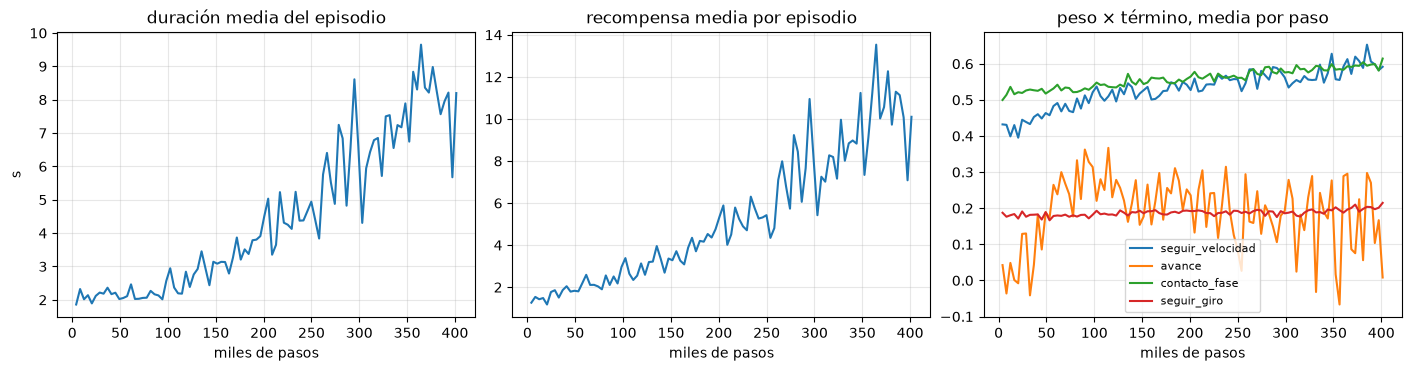

In [49]:
fig, ejes = plt.subplots(1, 3, figsize=(14, 3.6), layout="constrained")
ejes[0].plot(corto["pasos"] / 1e3, corto["duracion"] * 0.02)
ejes[0].set(xlabel="miles de pasos", ylabel="s", title="duración media del episodio")
ejes[1].plot(corto["pasos"] / 1e3, corto["recompensa"])
ejes[1].set(xlabel="miles de pasos", title="recompensa media por episodio")
for nombre in ["seguir_velocidad", "avance", "contacto_fase", "seguir_giro"]:
    ejes[2].plot(corto["pasos"] / 1e3, corto[nombre] / corto["duracion"] / 0.02, label=nombre)
ejes[2].set(xlabel="miles de pasos", title="peso × término, media por paso")
ejes[2].legend(fontsize=8)
for ax in ejes:
    ax.grid(alpha=0.3)
plt.show()

Qué cuentan las tres gráficas:

- **Duración** (izquierda): al principio Zancudo se cae en unos 2 s. A los 400.000 pasos aguanta **8-9 s de los 10** casi siempre. Lo primero que aprende la red es lo más urgente: **no caerse**, porque caerse corta el episodio y con él todos los premios que quedaban.
- **Recompensa** (centro): sube de 1-2 a unos 10-13 por episodio. Pero cuidado: sube sobre todo **porque dura más**. Por eso la tercera gráfica divide por la duración.
- **Términos por paso** (derecha): `contacto_fase` y `seguir_velocidad` suben poco a poco (de 0,4-0,5 a 0,6); `seguir_giro` se queda plano en 0,2; y `avance`, el que de verdad dice "te estás moviendo hacia donde te piden", **da saltos** entre 0 y 0,35 sin tendencia clara. Es la huella de la trampa de la sección 5: la red ha aprendido a sostenerse y a marcar el paso, pero aún no a desplazarse.

¿Y qué hace? Evaluamos la política con órdenes fijas (3 episodios de 10 s cada una, con semillas que no se usaron al entrenar), con la función `evaluar` del paquete, que mide la velocidad media conseguida (sin contar el primer segundo, de arranque):


In [50]:
politica_corta = Politica("practica_nb54/corto")
print(f"{'orden (vx, vy, giro)':>22} | {'dura (s)':>8} | {'vx':>6} | {'vy':>6} | {'giro':>6}")
for orden in [[0.0, 0.0, 0.0], [0.4, 0.0, 0.0], [0.0, 0.0, 0.4]]:
    r = evaluar(politica_corta, orden, episodios=3)
    print(f"{str(orden):>22} | {r['duracion']:8.1f} | {r['vx']:6.2f} | {r['vy']:6.2f} | {r['giro']:6.2f}")

  orden (vx, vy, giro) | dura (s) |     vx |     vy |   giro


       [0.0, 0.0, 0.0] |     10.0 |  -0.00 |  -0.01 |   0.02


       [0.4, 0.0, 0.0] |     10.0 |  -0.00 |  -0.01 |   0.00


       [0.0, 0.0, 0.4] |     10.0 |   0.00 |  -0.01 |   0.02


Lo que esperábamos, y lo que pasó en la primera prueba de pesos: a los 400.000 pasos, Zancudo **aguanta los 10 s de pie con cualquier orden... y no se mueve** (0,00 m/s con la orden de 0,4; 0,02 rad/s con la orden de girar a 0,4). Está en el óptimo local de quedarse quieto: de momento, es lo que más le renta.

No es un fracaso: es **el principio** de la curva. 400.000 pasos son el 4 % del entrenamiento largo. Para ver cómo sale de la trampa, hace falta mucho más tiempo, y eso es lo que viene ahora.


## 11 · El entrenamiento largo

### Lanzarlo en segundo plano

Para que Zancudo ande de verdad hacen falta **millones** de pasos (los laboratorios usan miles de millones). En la Pi, con los 4 núcleos, se consiguen entre 1.000 y 1.600 pasos por segundo (baja cuando los episodios se alargan y cuando la Pi se calienta): 10 millones son **unas 3 horas**. Eso no se hace dentro de un notebook. Se hace con la CLI, desde la terminal de la Pi, así:

```bash
cd ~/dev/robotica && mkdir -p trabajo_nb54
nohup venv/bin/python -m locomocion -v entrenar --pasos 10000000 --salida trabajo_nb54/largo \
      > trabajo_nb54/largo.out 2>&1 &
```

Pieza a pieza (NB05b, NB26):

- **`nohup`** (*no hang up*): que el programa **no muera** cuando cierres la terminal o se corte la conexión con la Pi.
- **`&`** al final: lánzalo **en segundo plano** y devuélveme la terminal.
- **`> trabajo_nb54/largo.out 2>&1`**: lo que escriba en la pantalla (la salida, `>`) y los errores (`2>`, que se mandan al mismo sitio que la salida, `&1`) van a un fichero.
- **`-v`**: nivel `INFO`. Además, la CLI escribe el registro en `trabajo_nb54/largo/entrenamiento.log`.

Mientras corre, para ver cómo va: **`tail -f trabajo_nb54/largo/entrenamiento.log`** (muestra las últimas líneas y se queda esperando las nuevas; se sale con Ctrl+C, sin parar el entrenamiento). Y si algo lo interrumpe, se reanuda con `--seguir`. Cada 200.000 pasos se guardan `modelo.zip` y `normalizacion.pkl`.

No es teoría: el entrenamiento de este notebook **se cortó** a los 528.000 pasos (se apagó la sesión). El último guardado era el de 401.408 pasos, así que se perdieron unos 2 minutos de trabajo, no horas. Se reanudó con

```bash
nohup venv/bin/python -m locomocion -v entrenar --seguir --pasos 9600000 --salida trabajo_nb54/largo \
      > trabajo_nb54/largo.out 2>&1 &
```

(con `--seguir`, `--pasos` cuenta los pasos **que faltan**: 401.408 + 9.600.000 ≈ 10 millones). Antes, se recortó `progreso.csv` a las filas de hasta 401.408 pasos, para no tener repetidas las tandas que se perdieron.

Al acabar, se copió lo importante a `notebooks/modelos/zancudo3d_andar/` (el modelo, su normalización, su `config.yaml`, `ajustes.json`, `progreso.csv` y el registro). Los modelos grandes de `trabajo_nb54/` no se suben a Git (`.gitignore`).

Las últimas líneas del registro:


In [51]:
LARGO = Path("modelos/zancudo3d_andar")
print(*(LARGO / "entrenamiento.log").read_text(encoding="utf-8").splitlines()[-4:], sep="\n")
print(sorted(p.name for p in LARGO.iterdir()))

02:39:52 INFO    locomocion.entrenamiento: pasos 9904128 | recompensa 34.05 | duración 500 | seguir_velocidad 9.598 | 1226 pasos/s
02:40:21 INFO    locomocion.entrenamiento: pasos 9945088 | recompensa 36.79 | duración 500 | seguir_velocidad 9.526 | 1227 pasos/s
02:40:46 INFO    locomocion.entrenamiento: pasos 9986048 | recompensa 35.42 | duración 500 | seguir_velocidad 9.450 | 1228 pasos/s
02:40:56 INFO    locomocion.entrenamiento: guardado en trabajo_nb54/largo (10002432 pasos)
['ajustes.json', 'config.yaml', 'entrenamiento.log', 'modelo.zip', 'normalizacion.pkl', 'progreso.csv']


El registro acaba en **10.002.432 pasos**, con el último guardado. Fíjate en las columnas: en las últimas tandas la **duración es 500** (los 500 pasos de 10 s: ningún episodio acaba en caída), la recompensa ronda 35 y el entrenamiento va a unos 1.230 pasos por segundo. (Si abres el fichero entero verás también las líneas del primer intento, el que se cortó: el registro se abre en modo "añadir", así que no se pierde la historia.)

### Las curvas


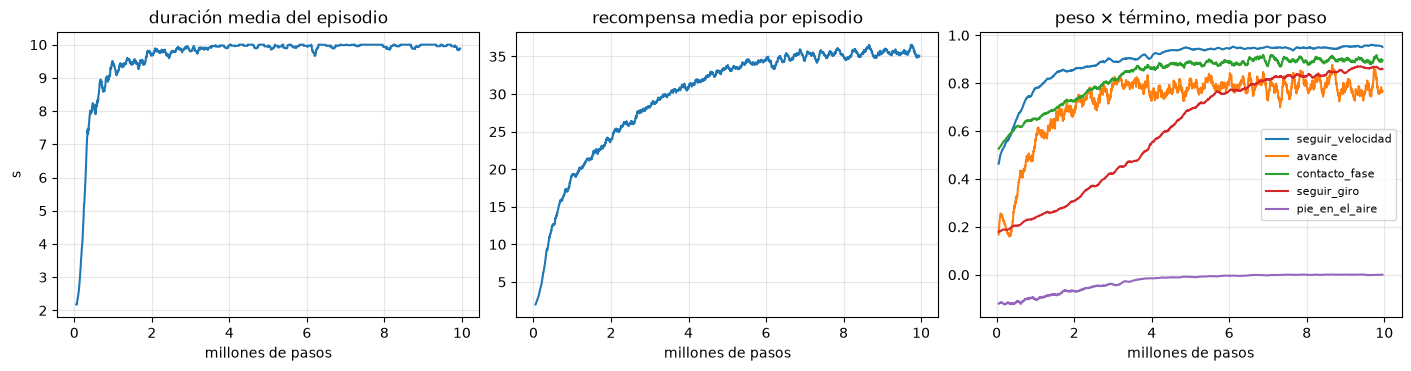

10.0 millones de pasos en 2.4 h


In [52]:
largo = leer_progreso(LARGO / "progreso.csv")
horas = largo["segundos"] / 3600

def suavizar(x, n=25):
    return np.convolve(x, np.ones(n) / n, mode="valid")

fig, ejes = plt.subplots(1, 3, figsize=(14, 3.6), layout="constrained")
ejes[0].plot(suavizar(largo["pasos"]) / 1e6, suavizar(largo["duracion"]) * 0.02)
ejes[0].set(xlabel="millones de pasos", ylabel="s", title="duración media del episodio")
ejes[1].plot(suavizar(largo["pasos"]) / 1e6, suavizar(largo["recompensa"]))
ejes[1].set(xlabel="millones de pasos", title="recompensa media por episodio")
for nombre in ["seguir_velocidad", "avance", "contacto_fase", "seguir_giro", "pie_en_el_aire"]:
    ejes[2].plot(suavizar(largo["pasos"]) / 1e6, suavizar(largo[nombre] / largo["duracion"] / 0.02), label=nombre)
ejes[2].set(xlabel="millones de pasos", title="peso × término, media por paso")
ejes[2].legend(fontsize=8)
for ax in ejes:
    ax.grid(alpha=0.3)
plt.show()
print(f"{largo['pasos'][-1] / 1e6:.1f} millones de pasos en {horas[-1]:.1f} h")

Unas **2,4 horas** de Pi para 10 millones de pasos. Las curvas están **suavizadas** (media móvil de 25 tandas, P6), porque cada tanda solo tiene unos 10 episodios y es muy ruidosa. Se leen como tres capítulos de una historia:

1. **Primero, no caerse** (0-2 millones). La duración sube de 2 a casi 10 s en el primer millón y medio. A partir de los 2 millones, prácticamente ningún episodio acaba en caída.
2. **Luego, ir a donde le piden** (1-4 millones). `avance` pasa de 0,2 a 0,8 por paso y `seguir_velocidad` de 0,5 a 0,9: Zancudo ha salido de la trampa de quedarse quieto. `pie_en_el_aire` deja de restar (de −0,12 a 0): ya no da pasitos de claqué.
3. **Por último, girar** (2-8 millones). `seguir_giro` es el término más lento: sube **en línea recta** de 0,2 a 0,85 durante seis millones de pasos. Lo comprobamos a medio camino: a los 4 millones, la política andaba recta a 0,50 m/s con la orden de 0,4, pero con la orden de girar a 0,4 rad/s giraba a 0,03. Girar sin caerse es más difícil que andar recto: hay que cargar el peso de forma asimétrica y torcer la cadera en el momento justo del paso.

Desde los 7-8 millones, la recompensa se queda en una **meseta** de unos 35: con esta recompensa, esta red y este número de robots, ya no mejora mucho. Seguir hasta 20 millones daría poco; para mejorar habría que cambiar algo (sección siguiente y NB55).

### ¿Obedece?

El examen de verdad: muchas órdenes distintas, cada una con 3 episodios de 10 s y semillas nuevas:


In [53]:
politica = Politica(LARGO)
ORDENES = [[0.0, 0.0, 0.0], [0.2, 0.0, 0.0], [0.4, 0.0, 0.0], [0.6, 0.0, 0.0], [-0.2, 0.0, 0.0],
           [0.0, 0.15, 0.0], [0.0, -0.15, 0.0], [0.0, 0.0, 0.4], [0.0, 0.0, -0.4], [0.3, 0.0, 0.3]]
print(f"{'orden (vx, vy, giro)':>22} | {'dura (s)':>8} | {'vx':>6} | {'vy':>6} | {'giro':>6}")
examen = {}
for orden in ORDENES:
    r = evaluar(politica, orden, episodios=3)
    examen[tuple(orden)] = r
    print(f"{str(orden):>22} | {r['duracion']:8.1f} | {r['vx']:6.2f} | {r['vy']:6.2f} | {r['giro']:6.2f}")

  orden (vx, vy, giro) | dura (s) |     vx |     vy |   giro


       [0.0, 0.0, 0.0] |     10.0 |   0.01 |  -0.01 |  -0.04


       [0.2, 0.0, 0.0] |     10.0 |   0.30 |  -0.00 |  -0.01


       [0.4, 0.0, 0.0] |     10.0 |   0.49 |   0.01 |   0.02


       [0.6, 0.0, 0.0] |      7.3 |   0.71 |   0.23 |  -0.38


...

      [0.0, 0.15, 0.0] |     10.0 |   0.00 |   0.21 |  -0.06


     [0.0, -0.15, 0.0] |     10.0 |   0.05 |  -0.22 |   0.05


       [0.0, 0.0, 0.4] |     10.0 |   0.02 |   0.06 |   0.37


      [0.0, 0.0, -0.4] |     10.0 |   0.02 |  -0.02 |  -0.37


       [0.3, 0.0, 0.3] |     10.0 |   0.40 |  -0.01 |   0.28


**Zancudo obedece.** Recorramos la tabla:

- **Quieto** ([0, 0, 0]): se queda en su sitio (0,01 m/s). Aprendido gracias al 10 % de episodios con orden de quietud (`prob_quieto`).
- **Hacia delante** (0,2 / 0,4): avanza, pero **se pasa**: 0,30 y 0,49 m/s, un 20-50 % más de lo pedido. **Hacia atrás** (−0,2): −0,26, también un poco de más.
- **De lado** (±0,15): se aparta de lado, a ±0,21-0,22 m/s, otra vez de más, y sin desviarse hacia delante.
- **Girar** (±0,4 rad/s): **0,37** en los dos sentidos, casi perfecto, y girando sobre sí mismo (0,02 m/s de avance).
- **Avanzar girando** ([0,3, 0, 0,3]): 0,40 m/s y 0,28 rad/s: **anda en curva**, las dos cosas a la vez.
- **El límite** (0,6 m/s): la duración media baja a **7,3 s**: alguno de los tres episodios acaba en caída, y antes de caer se tuerce (0,23 m/s de lado, −0,38 rad/s de giro). 0,6 es el extremo del rango de órdenes del entrenamiento (`comandos.vx` de −0,3 a 0,6), y en los extremos la red ha visto menos ejemplos.

¿Por qué se pasa de velocidad? Por la **campana**. Con σ = 0,25, pasarse 0,1 m/s cuesta exp(−0,1²/0,25) = 0,96: solo un 4 % del premio. Para la red, ir un poco deprisa es casi gratis, y probablemente le resulta **más estable** (como a ti te cuesta más andar muy despacio que a paso normal). Si quisiéramos precisión, se estrecha la campana al final del entrenamiento (un currículo de σ, NB55).

### Los pasos

¿Anda de verdad, alternando los pies? Los sensores de tacto lo dicen. Con la orden 0,4 m/s, dibujamos qué pie toca el suelo en cada instante durante 4 segundos (una barra por pie: llena = apoyado):


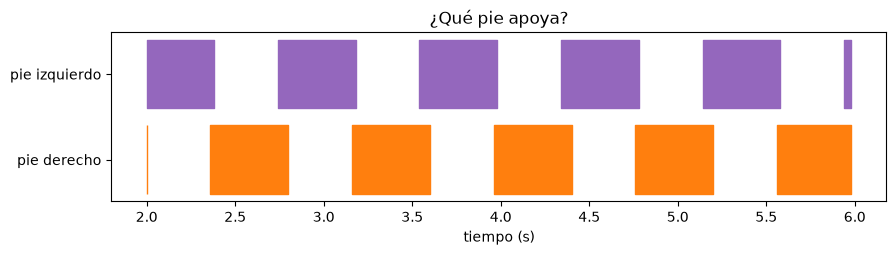

aterrizajes en 4 s: derecho 5, izquierdo 5;  los dos en el aire el 0 % del tiempo


In [54]:
entorno = ZancudoLocomocion(politica.config)
obs, _ = entorno.reset(seed=7, options={"comando": [0.4, 0.0, 0.0]})
contactos = []
for _ in range(300):
    obs, r, terminado, truncado, info = entorno.step(politica(obs))
    contactos.append(info["contacto"])
    if terminado:
        break
contactos = np.array(contactos)[100:]                                   # de 2 a 6 s
t = (np.arange(len(contactos)) + 100) * entorno.dt
fig, ax = plt.subplots(figsize=(10, 2.2))
for fila, (nombre, color) in enumerate([("derecho", "tab:orange"), ("izquierdo", "tab:purple")]):
    ax.fill_between(t, fila, fila + 0.8, where=contactos[:, fila], color=color, step="post")
ax.set(yticks=[0.4, 1.4], yticklabels=["pie derecho", "pie izquierdo"], xlabel="tiempo (s)", title="¿Qué pie apoya?")
plt.show()
aterrizajes = (contactos[1:] & ~contactos[:-1]).sum(axis=0)
print(f"aterrizajes en 4 s: derecho {aterrizajes[0]}, izquierdo {aterrizajes[1]};  "
      f"los dos en el aire el {100 * np.mean(~contactos.any(axis=1)):.0f} % del tiempo")

Es una **marcha de verdad**: los pies se alternan con un ritmo de reloj, 5 aterrizajes de cada pie en 4 s, es decir, un paso cada 0,8 s por pie, **exactamente** el `periodo_paso` de la configuración (0,8 s). El término `contacto_fase` ha hecho su trabajo: el reloj de la observación marca el compás y la red lo sigue.

Y los dos pies **nunca** están en el aire a la vez (0 %): cada pie aterriza un instante antes de que el otro despegue (las barras se solapan un poco). Eso es **andar**, con una pequeña fase de apoyo doble, como en el NB52; si hubiera fases con los dos pies en el aire, sería **correr**.

### Verlo

Un vídeo de 6 segundos con la orden 0,4 m/s, con la cámara lateral que sigue al robot (`render` del entorno):


x final: 2.88 m, y final: 0.22 m


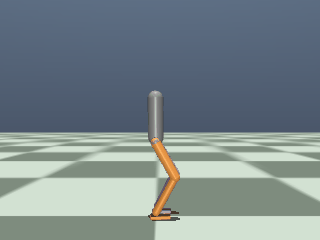

In [55]:
import imageio
from IPython.display import Image

entorno = ZancudoLocomocion(politica.config)
obs, _ = entorno.reset(seed=7, options={"comando": [0.4, 0.0, 0.0]})
fotos = []
for k in range(300):
    obs, r, terminado, truncado, info = entorno.step(politica(obs))
    if k % 2 == 0:
        fotos.append(entorno.render())
    if terminado:
        break
entorno.close()
Path("assets").mkdir(exist_ok=True)
imageio.mimsave("assets/nb54_zancudo3d_anda.gif", fotos, fps=25, loop=0)
print(f"x final: {entorno.datos.qpos[0]:.2f} m, y final: {entorno.datos.qpos[1]:.2f} m")
Image(filename="assets/nb54_zancudo3d_anda.gif")

En 6 s, unos 2,9 m: la media es ~0,48 m/s, lo mismo que medimos en el examen. Y se desvía solo 22 cm de lado en ese recorrido.

Mira cómo anda: **agachado**, con las rodillas muy dobladas y el torso recto. No se lo pedimos (el término `altura` solo le pide llevar el torso a unos 0,75 m, y como castiga el error **al cuadrado**, apartarse unos centímetros apenas cuesta), pero es la marcha que suelen encontrar las políticas de RL: con las rodillas dobladas, las piernas tienen **margen** para estirarse y encogerse rápido y corregir, igual que tú doblas las rodillas cuando el suelo resbala. Los humanoides de verdad (y las personas) andan con las rodillas casi rectas porque **gastan menos energía**; nuestra recompensa apenas castiga el gasto (`par` con peso −0,00001), así que a Zancudo le da igual.

### Balance honesto, y qué haría falta

Lo que **funciona**, en una Raspberry Pi y en 2,4 horas:

- Una política que obedece órdenes de velocidad hacia delante, hacia atrás, de lado, de giro y combinadas, sin caerse en 10 s (salvo en el extremo de 0,6 m/s).
- Con una marcha alternada, al compás del reloj, con apoyo doble.
- Todo en un paquete instalable, reproducible (configuración, ajustes y semilla guardados junto al modelo), probado con pytest y entrenado desde la terminal, con reanudación incluida.

Lo que **no** funciona todavía, o funciona solo en el simulador:

1. **Se pasa de velocidad** un 20-50 %. Se arregla afinando la recompensa (campana más estrecha al final, currículo).
2. **Solo conoce un mundo perfecto**: suelo plano, masas exactas, motores ideales, sin retrasos, sin empujones. Si cambias algo (rozamiento, masa del torso, un empujón), probablemente se cae. Es la práctica del NB43 en 3D. Se arregla con **aleatorización de dominio**: NB55.
3. **Usa la velocidad lineal privilegiada**, que un robot real no mide directamente (sección 6). NB61.
4. **Anda agachado** y gasta energía de más. Se arregla con términos de energía y de postura, o imitando un movimiento de referencia: NB57.
5. **Una sola semilla.** Con otra semilla, la marcha podría salir distinta, o peor. Un resultado serio se repite con 3-5 semillas (NB43). En la Pi, cada una son 2,4 horas.

Y lo que **haría falta** para acercarse a un laboratorio: muchos más robots a la vez y muchos más pasos. legged_gym entrena con 4.096 robots y ~1.000 millones de pasos en 20 minutos de GPU. Nosotros, 16 robots y 10 millones en 2,4 horas: **100 veces menos experiencia**, y aun así anda. Lo de GPU llega en el NB59 y el NB60.

### En Colab

Colab no tiene GPU que sirva para MuJoCo normal (la física va en la CPU), pero sus máquinas tienen más núcleos y más rápidos que la Pi, y no te bloquean el ordenador. El paquete se lleva tal cual:

```python
# En una celda de Colab (con el repositorio subido a GitHub, o el paquete en un .zip)
!git clone https://github.com/<tu_usuario>/robotica.git
!pip install -e robotica/paquetes/locomocion[entrenar]
!python -m locomocion -v entrenar --pasos 30000000 --entornos 32 --salida /content/largo
```

(Aquí sin `--no-deps`: en Colab sí queremos que instale MuJoCo, Gymnasium y SB3 si faltan.) Colab corta las sesiones largas: guarda la carpeta de salida en Google Drive y usa `--seguir` para reanudar. Para ir **mucho** más lejos (miles de robots a la vez), la física tiene que ir en la GPU: es **MJX** y **MuJoCo Playground** (NB59 y NB60), donde un entrenamiento como este tarda **minutos**.


## 12 · Resumen de la lección

1. **La tarea profesional**: seguir **órdenes de velocidad** (vx, vy, giro) en el marco del robot, sorteadas en cada episodio (con un 10 % de "quieto"). Una sola política para todas las órdenes, porque la orden está en la observación.
2. **Observación** (50 números), solo lo que un robot real puede medir y visto desde el robot: **gravedad proyectada** Rᵀ·(0, 0, −1) (inclinación sin rumbo, medible con la IMU), **velocidad angular** local (= giróscopo, `qvel[3:6]`), velocidad lineal en el marco del torso (Rᵀ·`qvel[0:3]`, **privilegiada**), la orden, **ángulos relativos a la postura por defecto**, velocidades articulares, **última acción** (Markov, suavidad), **reloj de fase** como (sen, cos). Sin posición ni rumbo: **invariancia** por construcción. Escalas para que todo ande por ±1.
3. **Acción**: objetivo = postura por defecto + escala · acción (0,3 rad), recortado a los rangos; servos blandos (kp 300, kv 10). **Decimación**: física cada 0,005 s, política cada 0,02 s (4 pasos de física por decisión).
4. **Recompensa modular**: términos pequeños registrados con un **decorador**, pesos en la configuración, cada término × peso × dt, **registrado por separado**. Seguimiento con la campana **exp(−error²/σ)**: acotada, positiva, afinada. La trampa del **óptimo local de quedarse quieto** (37 % del premio sin moverse con 0,5 m/s), y cómo se combate.
5. **Fin del episodio**: **terminado** (caída, NaN: el futuro vale 0) frente a **truncado** (tiempo: el futuro no vale 0). Reinicio con ruido; todo el azar desde `self.np_random` → misma semilla, mismo episodio.
6. **Paquete instalable**: *src layout*, `pyproject.toml` (build-system, project, dependencias opcionales, scripts, package-data, configuración de herramientas), datos del paquete con `importlib.resources`, `pip install -e` (un `.pth` que apunta a `src/`), registro en Gymnasium.
7. **CLI** con `argparse`: subórdenes, `parents`, `count`, `append`, `nargs`, `store_true`, `main(argv)` probable y con código de salida; `python -m paquete` con `__main__.py`; orden de la terminal con `[project.scripts]`; cambios `--set a.b=valor` (con la trampa de YAML).
8. **logging** en el programa: nivel por `-v`, a pantalla y a fichero, con hora y módulo.
9. **pytest**: *fixtures* en `conftest.py` (ámbito, `yield` para limpiar, fixtures que usan fixtures, `tmp_path`), `parametrize`, `raises(match=)`, `approx`, `importorskip`; `check_env` de Gymnasium y SB3, determinismo, signos de la gravedad.
10. **Entrenar en la Pi**: corto en vivo para ver que aprende; largo con la CLI en segundo plano (`nohup`), con guardados periódicos y un `progreso.csv` con cada término.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Orden de velocidad (*command*)** | La velocidad (vx, vy, giro) que se le pide al robot; parte de la observación. |
| **Gravedad proyectada** | La dirección de "abajo" vista desde el torso: Rᵀ·(0, 0, −1). |
| **Observación privilegiada** | Información que el simulador sabe pero un robot real no puede medir directamente. |
| **Invariancia** | Que la observación (y la política) no cambie con algo que no debería importar (posición, rumbo). |
| **Postura por defecto** | La postura alrededor de la cual se mide y se actúa; acción 0 = esa postura. |
| **Decimación** | Varios pasos de física por cada decisión de la política. |
| **Recompensa modular** | Suma de términos con nombre y peso, configurables y registrados por separado. |
| **Terminado / truncado** | Fin por algo del mundo (el futuro vale 0) / fin por tiempo (el futuro no vale 0). |
| ***src layout*** | Estructura de proyecto con el paquete dentro de `src/`, para probar siempre lo instalado. |
| **Instalación editable** | `pip install -e`: el entorno apunta a tu carpeta; los cambios se ven sin reinstalar. |
| **Punto de entrada (*entry point*)** | Orden de la terminal creada al instalar, que llama a una función del paquete. |
| ***Fixture*** | Algo que pytest prepara (y limpia) para una prueba, pedido por el nombre del parámetro. |


## 13 · Preguntas de entrevista, con respuesta

**"¿Qué observa una política de locomoción típica?"**
Gravedad proyectada, velocidad angular de la base (giróscopo), a veces velocidad lineal de la base (estimada), las órdenes, posiciones articulares relativas a la postura por defecto, velocidades articulares, la última acción, y en bípedos un reloj de fase. Todo en el marco de la base y escalado. En terreno irregular se añade un mapa de alturas alrededor del robot (NB56).

**"¿Por qué la gravedad proyectada y no los ángulos de Euler?"**
Porque da la inclinación sin el rumbo (que no importa para el equilibrio y rompería la invariancia), no tiene saltos ni singularidades, y se mide con una IMU (el acelerómetro en reposo, fusionado con el giróscopo).

**"¿Por qué no se observa la posición del robot?"**
Porque un robot real no la conoce con precisión y porque no debe influir en cómo se anda: quitándola, la política es invariante a la traslación y al rumbo por construcción y no puede sobreajustarse a ellas.

**"¿Por qué la acción es un desplazamiento sobre una postura y no pares?"**
Con objetivos de PD alrededor de una postura estable, la política inicial (acciones ≈ 0) ya está más o menos de pie, y explora correcciones; los servos aportan estabilidad a alta frecuencia que la red no tiene que aprender. La escala limita el rango. Con pares directos, hay que aprender desde cero a no desplomarse, y el resultado depende mucho más del modelo de los motores.

**"¿Qué es la decimación?"**
Ejecutar varios pasos de física (y de PD) por cada decisión de la política: física a 200 Hz o más, política a 50 Hz. Abarata el entrenamiento (la red es lo caro), alarga el horizonte efectivo del descuento y es realista (el PD corre en el controlador del motor).

**"Diseña la recompensa para seguir órdenes de velocidad."**
Términos de seguimiento con exp(−‖v_orden − v‖²/σ) para la velocidad lineal en el plano y para la de giro; penalizaciones de regularización: velocidad vertical, velocidad angular en x e y, orientación (gravedad proyectada en el plano), altura, pares, cambio de acción, posiciones extremas; términos de marcha: tiempo de pie en el aire, contacto acorde con un reloj de fase; todo con pesos en la configuración, multiplicado por dt y registrado por términos. Y vigilar el óptimo local de quedarse quieto.

**"¿Terminated o truncated?"**
Terminated cuando el episodio acaba por el estado (caída): no hay valor futuro. Truncated cuando acaba por un límite externo (tiempo): el valor futuro existe y se estima con el crítico (*bootstrapping*). Confundirlos sesga el crítico.

**"¿Cómo organizarías el código de un proyecto de RL?"**
Como un paquete instalable (src layout, `pyproject.toml`), con la configuración separada del código (dataclasses + YAML, con validación y cambios desde la línea de órdenes), una CLI para entrenar y evaluar, logging a fichero, guardados periódicos con la configuración y los hiperparámetros junto al modelo, y pruebas automáticas del entorno (check_env, determinismo, signos, forma de la observación) antes de gastar horas de cálculo.


## 14 · Ejercicios

**E1.** Haz que la orden **cambie a mitad de episodio** cada 4 s (como legged_gym), con una **subclase** de `ZancudoLocomocion` que sobrescriba `step` (P3: herencia y `super()`). Comprueba con una semilla fija que en un episodio de 10 s hay tres órdenes distintas.

**E2.** Escribe una prueba de pytest para la CLI: que `main(["info"])` devuelve 0 y que lo que imprime contiene `"observación: (50,)"`. Usa la fixture de serie **`capsys`** (`capsys.readouterr().out` devuelve lo impreso). Ejecútala con pytest desde el notebook.

**E3.** Escribe un fichero de variante `practica_nb54/suave.yaml` con kp = 200, kv = 8 y una escala de acción de 0,25, y compruébalo con `locomocion info --config`.

**E4.** La velocidad lineal es privilegiada. Crea una subclase `ZancudoSinVelocidad` cuya observación **no** la incluya (47 números). ¿Qué tienes que cambiar además de `_observacion`? Pasa `check_env` de Gymnasium.

**E5.** Añade una prueba de **determinismo de la recompensa**: con la misma semilla y las mismas acciones, la recompensa total de 100 pasos es idéntica, y con otra semilla, distinta.

**E6.** Con el `progreso.csv` del entrenamiento largo (sección 11), dibuja cada término **dividido por la duración media del episodio** (es decir, por paso). Así se separa "gana más porque dura más" de "gana más porque lo hace mejor". ¿Qué términos mejoran de verdad?

**E7.** **Reto.** Escribe el término `pies_juntos` (castigo si los pies están a menos de 12 cm de lado, que se pisan) en el **paquete** (`recompensas.py`), dale un peso en una variante y comprueba con una prueba que aparece en `info["terminos"]`. ¿Por qué tiene que estar en el paquete, y no basta con definirlo en el notebook, si se entrena con `SubprocVecEnv`?


<details>
<summary>▶ Solución E1</summary>

```python
class OrdenesCambiantes(ZancudoLocomocion):
    """Como ZancudoLocomocion, pero la orden se vuelve a sortear cada `cada` segundos."""

    def __init__(self, config=None, cada=4.0, **kwargs):
        super().__init__(config, **kwargs)
        self.cada_pasos = round(cada / self.dt)

    def step(self, accion):
        if self.pasos > 0 and self.pasos % self.cada_pasos == 0:
            self.comando = self.muestrear_comando()
        return super().step(accion)

env = OrdenesCambiantes()
env.reset(seed=3)
ordenes, hecho = set(), False
while not hecho:
    obs, r, terminado, truncado, info = env.step(np.zeros(12, dtype=np.float32))
    ordenes.add(tuple(info["comando"].round(4)))
    hecho = terminado or truncado
print(len(ordenes), "órdenes distintas")
```

**3 órdenes** (en los pasos 0, 200 y 400: a los 0, 4 y 8 s). La subclase solo añade lo nuevo y delega el resto en la clase madre con `super()`; no se toca el paquete. Ojo: como `muestrear_comando` usa `self.np_random`, la secuencia de órdenes depende de la semilla y sigue siendo reproducible. Para entrenarla con `crear_entornos`, la clase tendría que estar en un módulo importable (ver E7).
</details>

<details>
<summary>▶ Solución E2</summary>

```python
Path("practica_nb54/test_cli.py").write_text("""
from locomocion.cli import main

def test_info(capsys):
    assert main(["info"]) == 0
    salida = capsys.readouterr().out
    assert "observación: (50,)" in salida
""", encoding="utf-8")
!{sys.executable} -m pytest practica_nb54/test_cli.py -q -p no:cacheprovider
```

`1 passed`. `capsys` captura lo que se escribe en la pantalla durante la prueba; `readouterr()` lo devuelve (y lo vacía). Probar la CLI llamando a `main` con una lista es mucho más rápido y fácil de depurar que lanzar un proceso de terminal por cada caso (aunque también se puede, con `subprocess.run` y su `returncode`, NB26).
</details>

<details>
<summary>▶ Solución E3</summary>

```python
Path("practica_nb54/suave.yaml").write_text("""
nombre: zancudo3d_suave
simulacion:
  kp: 200.0
  kv: 8.0
  escala_accion: 0.25
""", encoding="utf-8")
!{sys.executable} -m locomocion info --config practica_nb54/suave.yaml | head -8
```

La configuración resultante lleva `kp: 200.0`, `kv: 8.0` y `escala_accion: 0.25`, y todo lo demás de la base (fusión profunda, NB53). El fichero tiene solo lo que cambia; para entrenar con él: `locomocion entrenar --config practica_nb54/suave.yaml --salida ...`. Y como `entrenar` guarda `config.yaml` **completo** en la carpeta del resultado, el modelo sigue siendo reproducible aunque mañana cambies la base.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
from gymnasium import spaces
from gymnasium.utils.env_checker import check_env

class ZancudoSinVelocidad(ZancudoLocomocion):
    def __init__(self, config=None, **kwargs):
        super().__init__(config, **kwargs)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(47,), dtype=np.float32)

    def _observacion(self, medida):
        completa = super()._observacion(medida)
        return np.delete(completa, [6, 7, 8])          # la velocidad lineal ocupa las posiciones 6, 7 y 8

env = ZancudoSinVelocidad()
check_env(env, skip_render_check=True)
print(env.reset(seed=0)[0].shape)
```

Además de `_observacion`, hay que cambiar el **espacio de observación** (47 en vez de 50): si no, `check_env` protesta porque la observación no cabe en su espacio (y SB3 construiría una red con 50 entradas). La recompensa **sí** sigue usando la velocidad lineal: en simulación la sabemos, y premiar con información privilegiada está permitido (la recompensa no viaja al robot real; la política, sí). Esta idea, "el crítico y la recompensa ven más que la política", se llama **crítico asimétrico**, y es estándar en sim-to-real (NB61).
</details>

<details>
<summary>▶ Solución E5</summary>

```python
def recompensa_total(semilla, acciones):
    env = ZancudoLocomocion()
    env.reset(seed=semilla)
    total = 0.0
    for a in acciones:
        _, r, terminado, truncado, _ = env.step(a)
        total += r
        if terminado or truncado:
            break
    return total

acciones = np.random.default_rng(0).uniform(-1, 1, (100, 12)).astype(np.float32)
assert recompensa_total(5, acciones) == recompensa_total(5, acciones)
assert recompensa_total(5, acciones) != recompensa_total(6, acciones)
print(recompensa_total(5, acciones), recompensa_total(6, acciones))
```

Iguales con la misma semilla (comparadas con `==`, sin tolerancia: el simulador es determinista, NB49) y distintas con otra (cambian la orden y el ruido inicial). En el fichero de pruebas, `acciones` ya es una fixture: `def test_recompensa_determinista(config, acciones): ...`.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
tabla = leer_progreso("modelos/zancudo3d_andar/progreso.csv")       # la función de la sección 10
terminos = [c for c in tabla if c not in ("pasos", "segundos", "episodios", "recompensa", "duracion")]
fig, ax = plt.subplots(figsize=(10, 5))
for nombre in terminos:
    por_paso = tabla[nombre] / tabla["duracion"]
    suave = np.convolve(por_paso, np.ones(20) / 20, mode="valid")         # media móvil de 20 tandas
    ax.plot(tabla["pasos"][19:] / 1e6, suave, label=nombre)
ax.set(xlabel="millones de pasos", ylabel="término por paso")
ax.legend(ncol=3, fontsize=8)
plt.show()
```

(`np.convolve` con un "núcleo" de 20 unos/20 hace una **media móvil**: cada punto es la media de las 20 tandas anteriores, P6.) Dividir por la duración separa las dos cosas que se mezclan al principio del entrenamiento: casi todos los términos positivos suben solo porque el robot **dura** más. Por paso, se ve lo que mejora de verdad: los que más suben son `avance` y `seguir_giro` (unas 5 veces de principio a fin), y `seguir_velocidad` se duplica; `seguir_giro` es el último en subir, hasta los 8 millones. `vivo` es una raya plana (vale lo mismo en cada paso: solo suma por durar). Y las penalizaciones (`balanceo`, `orientacion`, `velocidad_vertical`, `pie_en_el_aire`, `accion_brusca`) se acercan a 0, señal de una marcha más tranquila.
</details>

<details>
<summary>▶ Solución E7</summary>

En `build_parts/nb54_locomocion/src/locomocion/recompensas.py` (la fuente del paquete), junto a los demás:

```python
@termino("pies_juntos")
def _pies_juntos(m: Medidas, cfg: Recompensa) -> float:
    return float(max(0.0, 0.12 - m.separacion_pies))
```

Para eso, `Medidas` necesita un campo nuevo, `separacion_pies`, que el entorno rellena en `step` (la distancia lateral entre los pies, en el marco del torso: `(R.T @ (xpos[pie_i] − xpos[pie_d]))[1]`). Después, una variante con `--set recompensa.pesos.pies_juntos=-10.0` y una prueba:

```python
def test_pies_juntos_aparece():
    env = ZancudoLocomocion(cargar_config(cambios=["recompensa.pesos.pies_juntos=-10.0"]))
    env.reset(seed=0)
    *_, info = env.step(np.zeros(12, dtype=np.float32))
    assert "pies_juntos" in info["terminos"]
```

¿Por qué en el paquete? Porque `SubprocVecEnv` crea los entornos en **otros procesos** (NB49), y esos procesos empiezan **importando el paquete** desde cero: no ven nada de lo que hayas definido en el notebook. Un término registrado solo en el notebook existiría en el proceso del notebook, y en los 16 procesos de los entornos daría "término de recompensa desconocido". Es una de las razones prácticas para meter el código en un paquete.
</details>


## 15 · 🛠 Práctica en MuJoCo: pon a prueba tu entorno

Un entorno nuevo hay que **interrogarlo** antes de gastar horas entrenándolo. Las pruebas de pytest comprueban que no hay fallos; esta práctica va más allá: usa los **sensores de MuJoCo** para comprobar que las observaciones significan lo que creemos, mide los dos relojes de la decimación, y pone números a la trampa de quedarse quieto. Todo con el entorno de verdad, el del paquete.

### Paso 1 · La IMU frente a la observación

Un robot real no tiene `xmat`: tiene una **IMU** (NB41). Si nuestra gravedad proyectada es correcta, tiene que coincidir con lo que diría el **acelerómetro** de Zancudo cuando está quieto: el acelerómetro mide la reacción a la gravedad (hacia arriba, 9,81 m/s²), así que gravedad ≈ −a/|a|. Creamos el entorno, lo dejamos asentarse 1 s con acción 0, y comparamos:


In [56]:
entorno = ZancudoLocomocion()
obs, _ = entorno.reset(seed=0, options={"comando": [0.0, 0.0, 0.0]})
for _ in range(50):                                            # 1 s de pie
    obs, *_ = entorno.step(np.zeros(12, dtype=np.float32))
a = entorno.datos.sensor("acelerometro").data
print("acelerómetro (m/s²):           ", a.round(3))
print("−a/|a| (lo que diría la IMU):  ", (-a / np.linalg.norm(a)).round(4))
print("gravedad proyectada (obs[:3]): ", obs[:3].round(4))

acelerómetro (m/s²):            [-0.03  -0.012 11.498]
−a/|a| (lo que diría la IMU):   [ 0.0026  0.0011 -1.    ]
gravedad proyectada (obs[:3]):  [-0.0252  0.0016 -0.9997]


Coinciden hasta el cuarto decimal: el acelerómetro marca unos 9,81 m/s² "hacia arriba" del torso, y su dirección, cambiada de signo, es nuestra gravedad proyectada. (El site `imu` tiene los mismos ejes que el torso, así que no hay que girar nada.)

### Paso 2 · ...pero no cuando se mueve

Ahora, lo mismo **mientras el robot se agita**: acciones al azar durante 0,4 s. Comparamos, paso a paso, el ángulo entre la estimación del acelerómetro y la gravedad de verdad:


In [57]:
rng = np.random.default_rng(0)
errores = []
for _ in range(20):
    obs, *_ = entorno.step(rng.uniform(-1, 1, 12).astype(np.float32))
    a = entorno.datos.sensor("acelerometro").data
    estimada = -a / np.linalg.norm(a)
    errores.append(math.degrees(math.acos(np.clip(estimada @ obs[:3], -1, 1))))
print("error de la IMU (grados), paso a paso:", np.round(errores, 1))

error de la IMU (grados), paso a paso: [ 18.9  86.5  60.   10.2  25.1  99.7  93.6  96.9 127.   73.8  24.3  58.5  30.9  57.1   8.1  12.3 119.7  99.9  60.1
 103.5]


Con el robot agitándose, el acelerómetro se equivoca **decenas de grados**: además de la gravedad, mide las **aceleraciones** del torso (no puede distinguirlas, es el principio de equivalencia de Einstein en pequeño). Por eso un robot real no usa el acelerómetro solo: lo **fusiona** con el giróscopo (que mide bien los giros rápidos pero se desvía con el tiempo) en un filtro (complementario o de Kalman, NB41). En simulación usamos la gravedad "perfecta", que es lo que ese filtro intenta dar; en el NB55 le añadiremos **ruido** para que la política no se fíe demasiado.

### Paso 3 · Los dos relojes

¿Avanza de verdad la física 0,02 s por cada `step`, en 4 pasitos? `datos.time` es el reloj de MuJoCo:


In [58]:
antes = entorno.datos.time
entorno.step(np.zeros(12, dtype=np.float32))
print(f"un step de la política: {entorno.datos.time - antes:.4f} s de física "
      f"= {round((entorno.datos.time - antes) / entorno.modelo.opt.timestep)} pasos de {entorno.modelo.opt.timestep} s")

un step de la política: 0.0200 s de física = 4 pasos de 0.005 s


**0,02 s = 4 pasos de 0,005 s**: la decimación, medida con el reloj del simulador.

### Paso 4 · El listón de quedarse quieto

En la sección 7.4 viste que quedarse quieto con una orden de 0,4 m/s da mucha recompensa. Hagamos la tabla completa: para varias órdenes hacia delante, la recompensa de 10 s **sin moverse** (acción 0), y qué fracción del máximo de `seguir_velocidad` se lleva:


In [59]:
print(f"{'orden vx':>8} | {'recompensa quieto':>17} | {'seguir_velocidad':>16} | {'% del máximo':>12}")
for vx in [0.0, 0.2, 0.4, 0.6]:
    obs, _ = entorno.reset(seed=0, options={"comando": [vx, 0.0, 0.0]})
    total, hecho = 0.0, False
    while not hecho:
        obs, r, terminado, truncado, info = entorno.step(np.zeros(12, dtype=np.float32))
        total += r
        hecho = terminado or truncado
    seguir = info["episodio_terminos"]["seguir_velocidad"]
    print(f"{vx:8.1f} | {total:17.2f} | {seguir:16.2f} | {100 * seguir / 10:11.0f} %")

orden vx | recompensa quieto | seguir_velocidad | % del máximo


     0.0 |             31.20 |             9.95 |          99 %


     0.2 |             25.07 |             8.45 |          84 %


     0.4 |             21.91 |             5.22 |          52 %


     0.6 |             19.07 |             2.35 |          23 %


(El máximo de `seguir_velocidad` en 10 s es 1 × 500 pasos × 0,02 = 10.) Con órdenes pequeñas, quedarse quieto se lleva **casi todo** el premio de seguimiento (con 0,2 m/s, más del 85 %); incluso con 0,6 m/s, una cuarta parte. Para la red, aprender a andar solo compensa si **andar bien** da más que esto. Y al principio, andar mal da **mucho menos** (caerse corta el episodio). Ese es el muro que se ve en las curvas de la sección 10.

### Tus retos

**R1.** Repite el Paso 2 con el robot **cayéndose** (acción 0 y un empujón lateral de 150 N durante 0,2 s con `entorno.datos.xfrc_applied[torso]`, NB53). ¿Cuánto se equivoca el acelerómetro **durante la caída libre** del final?

**R2.** Con `cargar_config(cambios=["simulacion.decimacion=10"])`, comprueba con `datos.time` el nuevo `dt` de la política, y cuántos pasos por segundo da ahora el entorno (en `step`s de la política y en segundos de robot por segundo de reloj). ¿Qué ganas y qué pierdes?

**R3.** Haz la tabla del Paso 4 con **σ = 0,1** (más exigente). ¿Cuánto baja el listón de quedarse quieto? ¿Qué problema crees que tendría entrenar con σ tan pequeño desde el principio?


<details>
<summary>▶ Solución R1</summary>

```python
obs, _ = entorno.reset(seed=0, options={"comando": [0, 0, 0]})
torso = entorno.ind.torso
for k in range(150):                                         # 3 s
    entorno.datos.xfrc_applied[torso, 1] = 150.0 if 25 <= k < 35 else 0.0
    obs, r, terminado, truncado, _ = entorno.step(np.zeros(12, dtype=np.float32))
    a = entorno.datos.sensor("acelerometro").data
    error = math.degrees(math.acos(np.clip((-a / np.linalg.norm(a)) @ obs[:3], -1, 1)))
    if k % 5 == 0 or terminado:
        print(f"t = {k * 0.02:.2f} s   |a| = {np.linalg.norm(a):5.2f} m/s²   error {error:5.1f}°")
    if terminado:
        break
```

Antes del empujón, error casi 0 y |a| ≈ 9,8. Durante el empujón y la caída, el error crece a decenas de grados. Y si el torso llega a estar casi en **caída libre**, |a| baja mucho: un acelerómetro en caída libre mide **cero** (por eso los astronautas "flotan"), y la dirección −a/|a| deja de significar nada. La gravedad proyectada, en cambio, sigue diciendo exactamente cuánto está inclinado. Moraleja: la observación de simulación es la de un **filtro perfecto**; la real será peor.
</details>

<details>
<summary>▶ Solución R2</summary>

```python
lento = ZancudoLocomocion(cargar_config(cambios=["simulacion.decimacion=10"]))
lento.reset(seed=0)
antes = lento.datos.time
lento.step(np.zeros(12, dtype=np.float32))
print("dt de la política:", round(lento.datos.time - antes, 4), "s  (", lento.dt, ")")
inicio = time.perf_counter()
for _ in range(200):
    lento.step(np.zeros(12, dtype=np.float32))
segundos = time.perf_counter() - inicio
print(f"{200 / segundos:.0f} steps/s   = {200 * lento.dt / segundos:.0f} s de robot por segundo")
```

`dt` = **0,05 s** (20 decisiones por segundo). Hay menos `step`s por segundo (cada uno lleva 10 pasos de física), pero **más segundos de robot por segundo de reloj**, porque la parte fija de cada `step` (observación, recompensa, y al entrenar, la red) se reparte entre más física. Lo que pierdes: el robot reacciona solo cada 50 ms, y un bípedo necesita corregir rápido (un paso entero dura unos 400 ms). Además, el episodio sigue siendo de 10 s, pero ahora son 200 decisiones: la recompensa por decisión cambia, y por eso los términos se multiplican por `dt`.
</details>

<details>
<summary>▶ Solución R3</summary>

```python
exigente = ZancudoLocomocion(cargar_config(cambios=["recompensa.sigma=0.1"]))
for vx in [0.2, 0.4, 0.6]:
    obs, _ = exigente.reset(seed=0, options={"comando": [vx, 0.0, 0.0]})
    hecho = False
    while not hecho:
        obs, r, terminado, truncado, info = exigente.step(np.zeros(12, dtype=np.float32))
        hecho = terminado or truncado
    print(vx, f"{10 * info['episodio_terminos']['seguir_velocidad']:.0f} % del máximo")
```

Con σ = 0,1, quedarse quieto se lleva mucho menos: exp(−0,04/0,1) = 67 % con 0,2 m/s, exp(−0,16/0,1) = 20 % con 0,4 y exp(−0,36/0,1) = 3 % con 0,6. El problema de empezar así: la campana es tan estrecha que, al principio, **nada** de lo que hace la red (andar torpemente a 0,1 m/s cuando le piden 0,6) da premio de seguimiento, y no tiene ninguna pista de hacia dónde mejorar. Por eso los profesionales usan σ moderados, términos de "avance" que dan pistas desde lejos, o un **currículo**: empezar con órdenes pequeñas (o σ grande) y endurecer poco a poco. Lo veremos en el NB55.
</details>


### Qué has aprendido de MuJoCo hoy

- **La IMU simulada**: `datos.sensor("acelerometro")` y `"giroscopo"`. Quieto, −a/|a| es la gravedad proyectada; en movimiento, el acelerómetro mezcla gravedad y aceleraciones (y en caída libre mide 0). La observación de simulación es la de un filtro perfecto.
- **El giróscopo de MuJoCo es `qvel[3:6]`** de la junta libre (marco local), y la lineal hay que girarla con `xmat`.
- **Los dos relojes**: `datos.time` avanza `paso × decimacion` en cada `step` de la política; `modelo.opt.timestep` se puede cambiar al cargar (con `implicitfast`, 0,005 s es estable para Zancudo con servos blandos).
- **Cambiar servos de posición a mano**: `actuator_gainprm[:, 0]` y `actuator_biasprm[:, 1:3]`.
- **Un entorno se interroga antes de entrenar**: recompensa de quedarse quieto, desglose por términos, coherencia con los sensores.

En la práctica del **NB55 (Robustez)** harás que este entorno deje de ser un mundo perfecto: masas y rozamientos al azar, empujones con `xfrc_applied`, ruido en la IMU y retraso en los motores, y medirás cuánto aguanta la política que has entrenado hoy.


## 16 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Ficheros que deja este notebook:

- **`paquetes/locomocion/`**: el paquete (instalado en modo editable en el `venv`). Su fuente "oficial" está en `build_parts/nb54_locomocion/`, desde donde la escriben las celdas `%%writefile`.
- **`notebooks/modelos/zancudo3d_andar/`**: la política del entrenamiento largo, con su `config.yaml`, `ajustes.json` y `progreso.csv`.
- **`notebooks/practica_nb54/`**: el entrenamiento corto y los ficheros de la práctica (no se suben a Git).

En el **NB55 · Robustez**, el robot de hoy se enfrenta al mundo imperfecto: **aleatorización de dominio** (masas, rozamientos, motores), **empujones**, **retrasos** y **currículo** (empezar fácil y endurecer). En Python: **wrappers** de Gymnasium, **callbacks** de SB3 a fondo, el `Generator` de NumPy y la reproducibilidad con muchas semillas.
